# Объединим датасеты

Мы получили датасет путем скрапинга, по апи, а также при использовании selenium. Теперь соединим их таким образом, чтобы объявление находилось сразу в обоих датасетах


In [2611]:
import pandas as pd
import numpy as np

In [2612]:
api_1_df = pd.read_csv('final_data.csv')
skrapping_df = pd.read_csv('url_final.csv')
selenium_api_df = pd.read_csv('selenium_final_data.csv')
selenium_scraping_df = pd.read_csv('selenium_cars_final_parsing.csv')

In [2613]:
selenium_scraping_df.head(3)

,url,title,year,city,make,model,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
0,http://www.bibika.ru/catalog/_bmw/_3-series/60...,BMW 3-series F30/F31/F34 320i xDrive AT (184 л...,2014,Саратов,bmw,3-series,2200.0,"инжектор, 2.0 л.",NaN,190000.0,NaN,седан,синий,NaN,184.0,Машиной владею с 2014 года. Покупал в Толсар С...
1,http://www.bibika.ru/catalog/_bmw/_x5/6007076,BMW X5 4.4 V8 xDrive M Competition 2024г за 8....,2024,Корея,bmw,x5,8400.0,"бензин, 4.4 л.",NaN,7000.0,NaN,внедорожник или кроссовер,белый,NaN,625.0,"BMW X5 M Competition 4.4 2024 года, пробег 6 7..."
2,http://www.bibika.ru/catalog/_bmw/_7-series/60...,BMW 7-series 2020г за 5 млн руб в Москве,2020,Москва,bmw,7-series,5000.0,"дизель, 3.0 л.",NaN,203000.0,NaN,седан,серый,NaN,249.0,NaN


In [2614]:
selenium_scraping_df.loc[selenium_scraping_df['price'] < 10000, 'price'] = selenium_scraping_df['price'] * 1000

In [2615]:
selenium_scraping_df.head(3)

,url,title,year,city,make,model,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
0,http://www.bibika.ru/catalog/_bmw/_3-series/60...,BMW 3-series F30/F31/F34 320i xDrive AT (184 л...,2014,Саратов,bmw,3-series,2200000.0,"инжектор, 2.0 л.",NaN,190000.0,NaN,седан,синий,NaN,184.0,Машиной владею с 2014 года. Покупал в Толсар С...
1,http://www.bibika.ru/catalog/_bmw/_x5/6007076,BMW X5 4.4 V8 xDrive M Competition 2024г за 8....,2024,Корея,bmw,x5,8400000.0,"бензин, 4.4 л.",NaN,7000.0,NaN,внедорожник или кроссовер,белый,NaN,625.0,"BMW X5 M Competition 4.4 2024 года, пробег 6 7..."
2,http://www.bibika.ru/catalog/_bmw/_7-series/60...,BMW 7-series 2020г за 5 млн руб в Москве,2020,Москва,bmw,7-series,5000000.0,"дизель, 3.0 л.",NaN,203000.0,NaN,седан,серый,NaN,249.0,NaN


In [2616]:
selenium_scraping_df['city'].unique()

array(['Саратов', 'Корея', 'Москва', 'Новокузнецк', 'Нижний Новгород',
       'Санкт-Петербург', 'Московская обл', 'Пятигорск', 'Тула',
       'Чебоксары', 'Грузия', 'Лен. область', 'Ижевск',
       'Набережные Челны', 'Краснодар', 'Беларусь', 'Ульяновск', 'Калуга',
       'Ярославль', 'Благовещенск', 'Белгород', 'Волгоград'], dtype=object)

In [2617]:
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Саратов', 'saratov')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Корея', 'koreya')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Москва', 'moskva')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Новокузнецк', 'novokuznetsk')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Нижний Новгород', 'nizhniy-novgorod')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Санкт-Петербург', 'spb')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Московская обл', 'moskva')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Пятигорск', 'pyatigorsk')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Тула', 'tyla')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Чебоксары', 'cheboksari')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Грузия', 'gruzia')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Лен. область', 'spb')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Ижевск', 'izhevsk')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Набережные Челны', 'naberezhnie chelni')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Краснодар', 'krasnodar')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Беларусь', 'belarus')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Ульяновск', 'ulianovsk')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Калуга', 'kaluga')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Ярославль', 'yaroslavl')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Ульяновск', 'ulianovsk')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Благовещенск', 'blagoveshinsk')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Белгород', 'belgorod')
selenium_scraping_df['city'] = selenium_scraping_df['city'].str.lower().replace('Волгоград', 'volgograd')


In [2618]:
api_1_df.head(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,front_crash_rating,side_crash_rating,rollover_rating,manufacturer_country,model_exists,marketcheck_avg_price,marketcheck_avg_days_on_market,marketcheck_popularity_score,matched_model_name,model_match_status
0,https://auto.drom.ru/ekaterinburg/toyota/crown...,toyota,crown,1990,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,False,NaN,NaN,0.0,NaN,not_found
1,https://auto.drom.ru/perm/hyundai/elantra/4754...,hyundai,elantra,2020,3,224,15,2,6,20,...,4,4,4,MEXICO,True,13370.82,294.74,1535.0,elantra,matched
2,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,toyota,camry,2019,6,361,18,0,1,21,...,5,5,5,UNITED STATES (USA),True,18882.84,238.00,1849.0,camry,matched


In [2619]:
api_1_df.shape

(10013, 21)

In [2620]:
skrapping_df.head(3)

,url,title,year,city,make,model,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
0,https://auto.drom.ru/ekaterinburg/toyota/crown...,"Продажа Toyota Crown, 1990 год в Екатеринбурге",1990.0,ekaterinburg,toyota,crown,500000.0,"бензин, 2.0 л",АКПП,280000.0,задний,седан,синий,правый,170.0,: Если машина интересна и готовы взять её под ...
1,https://auto.drom.ru/perm/hyundai/elantra/4754...,"Продажа Hyundai Elantra, 2020 год в Перми",2020.0,perm,hyundai,elantra,689000.0,"бензин, 2.0 л",АКПП,88000.0,передний,седан,серый,левый,150.0,: Федеральная сеть автосалонов Crystal Motors ...
2,https://auto.drom.ru/vsevolozhsk/toyota/camry/...,"Продажа Toyota Camry, 2019 год во Всеволожске",2019.0,vsevolozhsk,toyota,camry,1600000.0,"бензин, 2.0 л",АКПП,400000.0,передний,седан,белый,левый,150.0,: Машина ходовое вложение не требует Город : В...


In [2621]:
skrapping_df.shape

(10506, 16)

In [2622]:
selenium_df.head(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,front_crash_rating,side_crash_rating,rollover_rating,manufacturer_country,model_exists,marketcheck_avg_price,marketcheck_avg_days_on_market,marketcheck_popularity_score,matched_model_name,model_match_status
0,http://www.bibika.ru/catalog/_bmw/_3-series/60...,bmw,3-series,2014,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,False,NaN,NaN,0,NaN,not_found
1,http://www.bibika.ru/catalog/_bmw/_x5/6007076,bmw,x5,2024,7,137,3,0,1,7,...,4,5,4,GERMANY,True,55237.76,105.51,1621,x5,matched
2,http://www.bibika.ru/catalog/_bmw/_7-series/60...,bmw,7-series,2020,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,False,NaN,NaN,0,NaN,not_found


In [2623]:
df = pd.merge(api_1_df, skrapping_df, on = ['url', 'make', 'model', 'year'], how = 'inner')

In [2624]:
sel_df = pd.merge(selenium_api_df, selenium_scraping_df, on = ['url', 'make', 'model', 'year'], how = 'inner')

In [2625]:
sel_df.shape

(72, 33)

In [2626]:
df = pd.concat([df, sel_df], axis = 0)

In [2627]:
df.shape

(10085, 33)

In [2628]:
df.sample(3)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,price,engine,transmission,mileage,drive,body,color,wheel,hp,description
2734,https://auto.drom.ru/tambov/lada/kalina/163246...,lada,kalina,2011,0,0,0,0,0,0,...,310000.0,"бензин, 1.6 л",механика,107000.0,передний,хэтчбек 5 дв.,белый,NaN,84.0,NaN
5113,https://auto.drom.ru/novosibirsk/peugeot/408/9...,peugeot,408,2012,0,0,0,0,0,0,...,470000.0,"бензин, 1.6 л",механика,140000.0,передний,седан,черный,левый,120.0,: Автомобиль в отличном состоянии. Климат конт...
4225,https://auto.drom.ru/ekaterinburg/haval/jolion...,haval,jolion,2026,0,0,0,0,0,0,...,2449000.0,"бензин, 1.5 л",робот,NaN,передний,NaN,белый,левый,143.0,: Официальный дилер HAVAL CITY в городe Екaтер...


In [2629]:
df.duplicated().sum()

np.int64(0)

на всякий проверяем на дубликаты, но их и не будет, так как мы при сборе датасета их удаляли

In [2630]:
df.dtypes

,0
url,object
make,object
model,object
year,int64
recalls_count,int64
complaints_count,int64
injuries,int64
deaths,int64
has_fire,int64
has_crash,int64


Давайте приведем все к корректным типам данных. В целом, почти все типы данных корректны, только в столбцах, связанных с рейтингом должен быть float, а не object. Такое возникает потому что пропуск прописывается фразой 'Not Rated'. Давайте все такие значения заменим на Nan

In [2631]:
print('Количество Not Rated в overall_rating', (df['overall_rating'] == 'Not Rated').sum())
print('Количество Nan в overall_rating', df['overall_rating'].isna().sum())
print('Количество Not Rated в front_crash_rating', (df['front_crash_rating'] == 'Not Rated').sum())
print('Количество Nan в front_crash_rating', df['front_crash_rating'].isna().sum())
print('Количество Not Rated в side_crash_rating', (df['side_crash_rating'] == 'Not Rated').sum())
print('Количество Nan в side_crash_rating', df['side_crash_rating'].isna().sum())
print('Количество Not Rated в rollover_rating', (df['rollover_rating'] == 'Not Rated').sum())
print('Количество Nan в rollover_rating', df['rollover_rating'].isna().sum())

Количество Not Rated в overall_rating 2441
Количество Nan в overall_rating 6356
Количество Not Rated в front_crash_rating 2375
Количество Nan в front_crash_rating 6356
Количество Not Rated в side_crash_rating 2341
Количество Nan в side_crash_rating 6356
Количество Not Rated в rollover_rating 1657
Количество Nan в rollover_rating 6356


In [2632]:
df.loc[df['overall_rating'] == 'Not Rated', 'overall_rating'] = np.nan
df.loc[df['front_crash_rating'] == 'Not Rated', 'front_crash_rating'] = np.nan
df.loc[df['side_crash_rating'] == 'Not Rated', 'side_crash_rating'] = np.nan
df.loc[df['rollover_rating'] == 'Not Rated', 'rollover_rating'] = np.nan

In [2633]:
print('Количество Nan в overall_rating', df['overall_rating'].isna().sum())
print('Количество Nan в front_crash_rating', df['front_crash_rating'].isna().sum())
print('Количество Nan в side_crash_rating', df['side_crash_rating'].isna().sum())
print('Количество Nan в rollover_rating', df['rollover_rating'].isna().sum())

Количество Nan в overall_rating 8797
Количество Nan в front_crash_rating 8731
Количество Nan в side_crash_rating 8697
Количество Nan в rollover_rating 8013


In [2634]:
df['overall_rating'] = pd.to_numeric(df['overall_rating'])
df['front_crash_rating'] = pd.to_numeric(df['front_crash_rating'])
df['side_crash_rating'] = pd.to_numeric(df['side_crash_rating'])
df['rollover_rating'] = pd.to_numeric(df['rollover_rating'])

Поменяли на Nan, видим, что очень большое количество пропусков в этих столбцах, давайте в целом глянем на все пропуски

In [2635]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10085 entries, 0 to 71
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             10085 non-null  object 
 1   make                            10085 non-null  object 
 2   model                           10085 non-null  object 
 3   year                            10085 non-null  int64  
 4   recalls_count                   10085 non-null  int64  
 5   complaints_count                10085 non-null  int64  
 6   injuries                        10085 non-null  int64  
 7   deaths                          10085 non-null  int64  
 8   has_fire                        10085 non-null  int64  
 9   has_crash                       10085 non-null  int64  
 10  overall_rating                  1288 non-null   float64
 11  front_crash_rating              1354 non-null   float64
 12  side_crash_rating               1388 non

Вот теперь все супер! Все столбцы имеют корректные типы данных. После анализа одной переменной будем смотреть на пропуски

# Давайте посмотрим на корреляцию столбцов, принимающих числовые значения


In [2636]:
df_numeric = df[['year', 'recalls_count', 'complaints_count', 'injuries', 'deaths', 'has_fire', 'has_crash', 'overall_rating',
                'front_crash_rating', 'side_crash_rating', 'rollover_rating', 'price', 'mileage', 'hp']]
df_numeric.head(5)

,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,overall_rating,front_crash_rating,side_crash_rating,rollover_rating,price,mileage,hp
0,1990,0,0,0,0,0,0,NaN,NaN,NaN,NaN,500000.0,280000.0,170.0
1,2020,3,224,15,2,6,20,4.0,4.0,4.0,4.0,689000.0,88000.0,150.0
2,2019,6,361,18,0,1,21,5.0,5.0,5.0,5.0,1600000.0,400000.0,150.0
3,2007,3,88,19,0,1,11,NaN,NaN,NaN,NaN,450000.0,238000.0,102.0
4,2004,0,33,15,0,2,11,NaN,NaN,NaN,NaN,495000.0,NaN,102.0


In [2637]:
import plotly.express as px

corr_matrix = df_numeric.corr(method = 'spearman')
fig = px.imshow(corr_matrix, text_auto='.2f', color_continuous_scale='RdBu', title = 'Корреляция признаков между собой')
fig.show()

Данные хорошо разделяются по блокам: блок безопасности, блок мощности и блок влияния времени

Видим, что корреляция year и mileage -0.67 - это обозначает обратную зависимость, то есть когда увеличивается одна переменная, другая уменьшается. То есть уменьшение года сопровождается увеличением пробега

year и price имеют положиетльную зависимость, когда увеличивается одна переменная, увеличивается и вторая. Получается, что чем новее машина, тем больше ее цена


Видим еще квадратик голубой в левом верхнем углу. Как раз все эти признаки имеют положительную зависимость. Они все относятся к критериям безопасности и качества авто

Более того видим положительную зависимость между жалобами и пострадавшими

#  Univariant Analysis

Теперь давайте посмотрим как у нас выглядит каждый признак


**url** - ссылка на объявление, в нашем случае уникальный идентификатор автомобиля. Именно по ссылке производился весь сбор данных в скрапинге


**1.make** - производитель (марка) автомобиля

**2.model** - модель автомобиля

**3.year** - год выпуска конкретного автомобиля

**4.recalls_count** - количество отзывных компаний на конкретную модель автомобиля

**5.complaints_count** - количество жалоб на конкретную модель

**6.injuries** - количесвтво травмы, полученные при использовании данной модели авто

**7.deaths** - колчество умерших, при использовании данной модели авто

**8.has_fire** -колчество возгораний данной модели авто

**9.has_crash** - количество аварий данной модели авто

**10.overall_rating** - общий рейтинг безопасности авто

**11.front_crash_rating** - рейтинг безопасности авто при столкновении прямо

**12.side_crash_rating** - рейтинг безопасности авто при столкновении боком

**13.rollover_rating** - рейтинг безопасности авто при перевороте

**14.manufacturer_country** - страна выпуска модели автомобиля

**15.model_exists** - маркер о существовании такой модели автомобиля. Технический столбец, сразу удаляем

**16.title** - заголовок объявления о продаже конкретного авто

**17.city** - город, в котором осуществляется продажа конкретного авто

**18.price** - цена конкретного автомобиля

**19.engine** - тип топлива, объем двигателя и дополнительное оборудование

**20.transmission** - тип коробки передач у конкретного автомобиля

**21.mileage** - пробег конкретного автомобиля

**22.drive** - тип привода конкретного автомобиля

**23.body** - тип кузова конкретного автомобиля

**24.color** - цвет конкретного автомобиля

**25.wheel** - расположение руля в конкретном автомобиле

**26.hp** - количество лошадиных сил конкретного автомобиля

**27.description** - описание автомобиля, взятое из объявления

**28. marketcheck_avg_price** - средня цена по рынку на эту модель этого года

**29. marketcheck_avg_days_on_market** - среднее количество дней сколько висит объявление

**30. marketcheck_popularity_score** - оценка популярности авто на рынке

**31. matched_model_name** - название по которому нашелся результат в апи. Технический столбец, сразу удаляем

**32. model_match_status** - статус тип найдено в апи или не найдено. Технический столбец, сразу удаляем

часто содержит очень полезную дополнительную информацию, источник продажи (собственник или автосалон) и остальные нюансы(количество собственников, дтп)



Давайте теперь посмотрим на каждый признак по отдельности


**1.make** - производитель (марка) автомобиля

давайте в целом посмотрим, сколько объявлений о продаже приходится на конкретные марки авто

In [2638]:
make_pivot = pd.pivot_table(df, values = 'url', index = 'make', aggfunc = 'count').sort_values(by = 'url')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'dodge'),
  Text(1, 0, 'zeekr'),
  Text(2, 0, 'geely'),
  Text(3, 0, 'chevrolet'),
  Text(4, 0, 'lexus'),
  Text(5, 0, 'tesla'),
  Text(6, 0, 'mini'),
  Text(7, 0, 'porsche'),
  Text(8, 0, 'subaru'),
  Text(9, 0, 'suzuki'),
  Text(10, 0, 'jeep'),
  Text(11, 0, 'jaguar'),
  Text(12, 0, 'cadillac'),
  Text(13, 0, 'infiniti'),
  Text(14, 0, 'volvo'),
  Text(15, 0, 'opel'),
  Text(16, 0, 'fiat'),
  Text(17, 0, 'citroen'),
  Text(18, 0, 'chery'),
  Text(19, 0, 'skoda'),
  Text(20, 0, 'mercedes-benz'),
  Text(21, 0, 'haval'),
  Text(22, 0, 'audi'),
  Text(23, 0, 'lada'),
  Text(24, 0, 'peugeot'),
  Text(25, 0, 'hyundai'),
  Text(26, 0, 'nissan'),
  Text(27, 0, 'toyota'),
  Text(28, 0, 'volkswagen'),
  Text(29, 0, 'renault'),
  Text(30, 0, 'honda'),
  Text(31, 0, 'mazda'),
  T

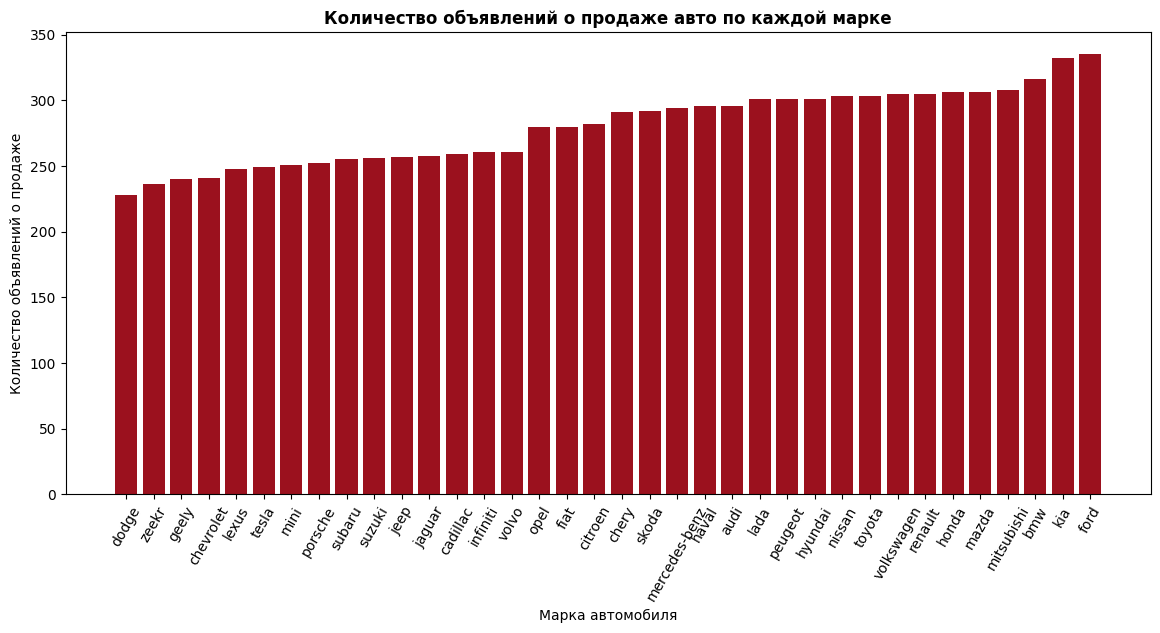

In [2639]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 6))
plt.bar(make_pivot.index, make_pivot['url'], color = '#9B111E')


plt.title('Количество объявлений о продаже авто по каждой марке', fontweight = 'bold')
plt.xlabel('Марка автомобиля')
plt.ylabel('Количество объявлений о продаже')
plt.xticks(rotation = 60)

В целом все марки авто практически равномерно представлены в датасете, наименее популярная марка - dodge, а наиболее популярная kia и ford

2.model - модель автомобиля

здесь будем рассматривать количество различных моделей авто у одного производителя (марки)

In [2640]:
model_pivot = pd.pivot_table(df, values = 'model', index = 'make', aggfunc = 'nunique').sort_values(by = 'model')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'tesla'),
  Text(1, 0, 'zeekr'),
  Text(2, 0, 'mini'),
  Text(3, 0, 'porsche'),
  Text(4, 0, 'skoda'),
  Text(5, 0, 'jeep'),
  Text(6, 0, 'haval'),
  Text(7, 0, 'jaguar'),
  Text(8, 0, 'cadillac'),
  Text(9, 0, 'subaru'),
  Text(10, 0, 'opel'),
  Text(11, 0, 'geely'),
  Text(12, 0, 'dodge'),
  Text(13, 0, 'renault'),
  Text(14, 0, 'bmw'),
  Text(15, 0, 'chevrolet'),
  Text(16, 0, 'volvo'),
  Text(17, 0, 'audi'),
  Text(18, 0, 'peugeot'),
  Text(19, 0, 'fiat'),
  Text(20, 0, 'ford'),
  Text(21, 0, 'chery'),
  Text(22, 0, 'suzuki'),
  Text(23, 0, 'volkswagen'),
  Text(24, 0, 'hyundai'),
  Text(25, 0, 'mercedes-benz'),
  Text(26, 0, 'citroen'),
  Text(27, 0, 'infiniti'),
  Text(28, 0, 'kia'),
  Text(29, 0, 'lada'),
  Text(30, 0, 'mazda'),
  Text(31, 0, 'mitsubishi'),
  Tex

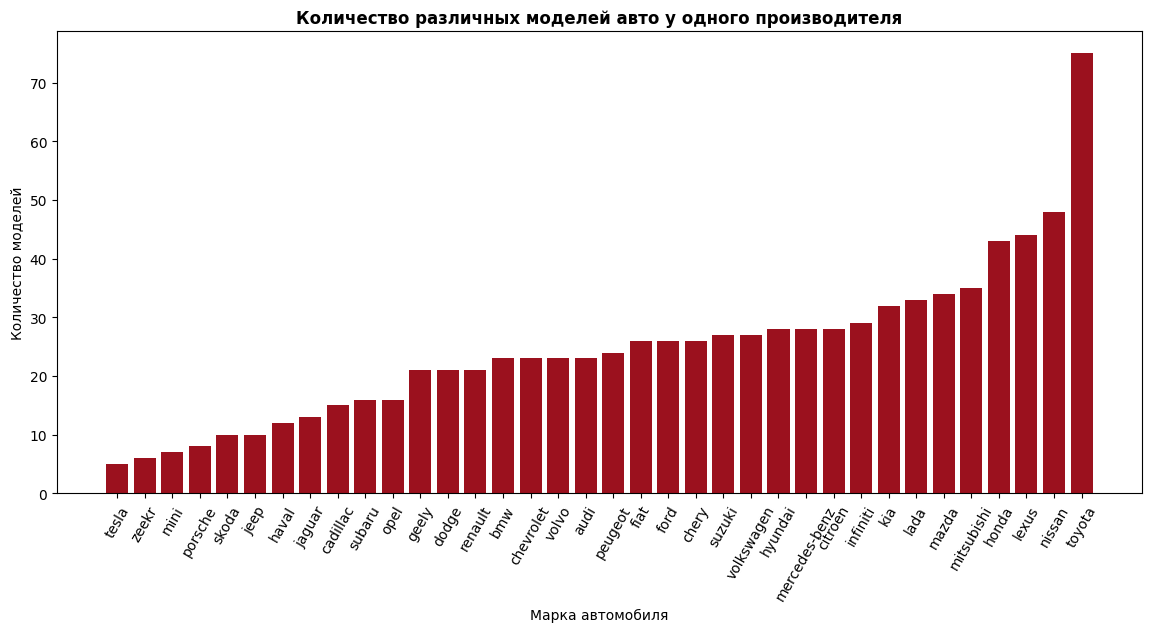

In [2641]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14, 6))
plt.bar(model_pivot.index, model_pivot['model'], color = '#9B111E')


plt.title('Количество различных моделей авто у одного производителя', fontweight = 'bold')
plt.xlabel('Марка автомобиля')
plt.ylabel('Количество моделей')
plt.xticks(rotation = 60)

Разные марки имеют разное количество моделей автомобиля, лидером по количеству моделей является toyota, в то время как tesla и zeekr занимают последние места - вероятно из-за того, что это достаточно молодые бренды в сравнии с другим

3.year - год выпуска конкретного автомобиля

давайте посмотрим как автомобили из нашего датасета распределены по годам производства

In [2642]:
years_pivot = pd.pivot_table(df, values = 'url', index = 'year', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей')

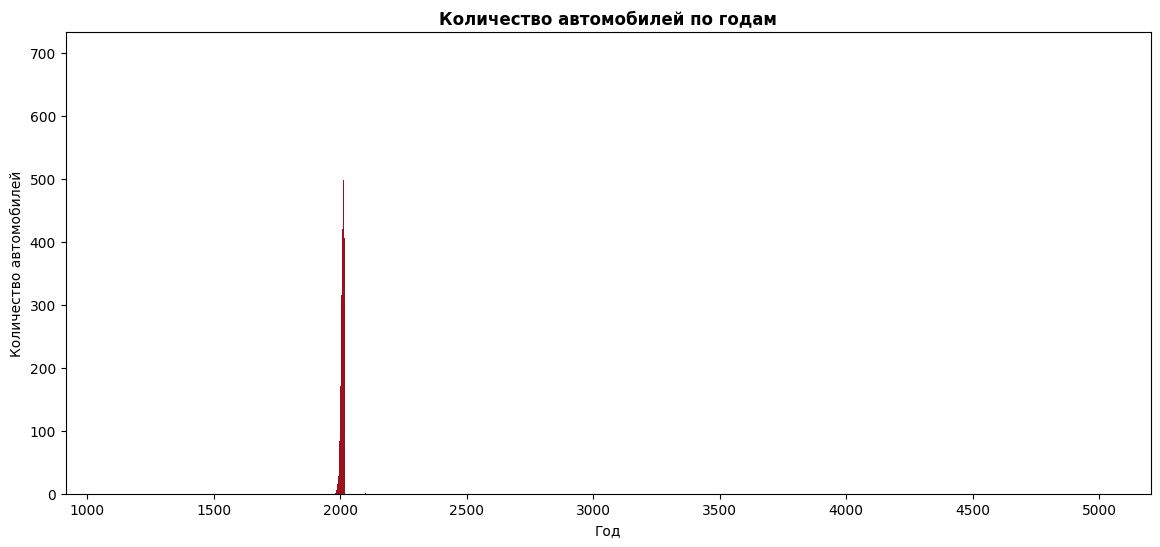

In [2643]:
plt.figure(figsize = (14, 6))
plt.bar(years_pivot.index, years_pivot['url'], color = '#9B111E')


plt.title('Количество автомобилей по годам', fontweight = 'bold')
plt.xlabel('Год')
plt.ylabel('Количество автомобилей')


In [2644]:
df = df[df['year'] <= 2026]
df = df[df['year'] >= 1980]


In [2645]:
years_pivot = pd.pivot_table(df, values = 'url', index = 'year', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей')

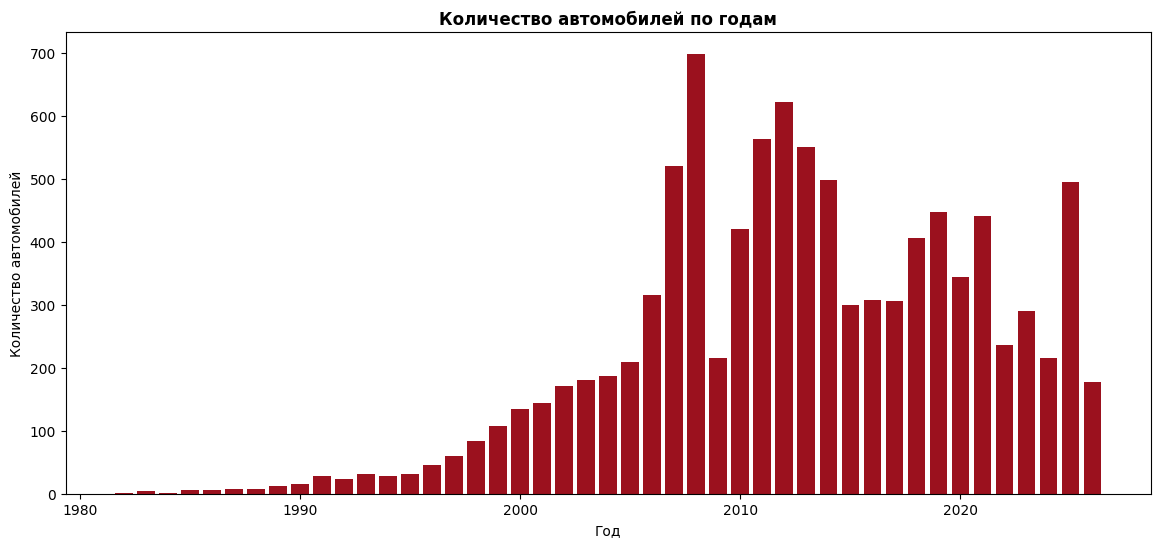

In [2646]:
plt.figure(figsize = (14, 6))
plt.bar(years_pivot.index, years_pivot['url'], color = '#9B111E')


plt.title('Количество автомобилей по годам', fontweight = 'bold')
plt.xlabel('Год')
plt.ylabel('Количество автомобилей')

В датасете представлены преимущественно свежие автомобили. Наибольшее количество продающихся авто - от 2006 года производства. Пик по количеству у машин 2008 года выпуска

4.recalls_count - количество отзывных компаний на конкретную модель автомобиля

In [2647]:
recalls_table = df['recalls_count'].value_counts().sort_index()
recalls_table

,count
recalls_count,
0,6116
1,477
2,595
3,533
4,460
5,343
6,321
7,228
8,94


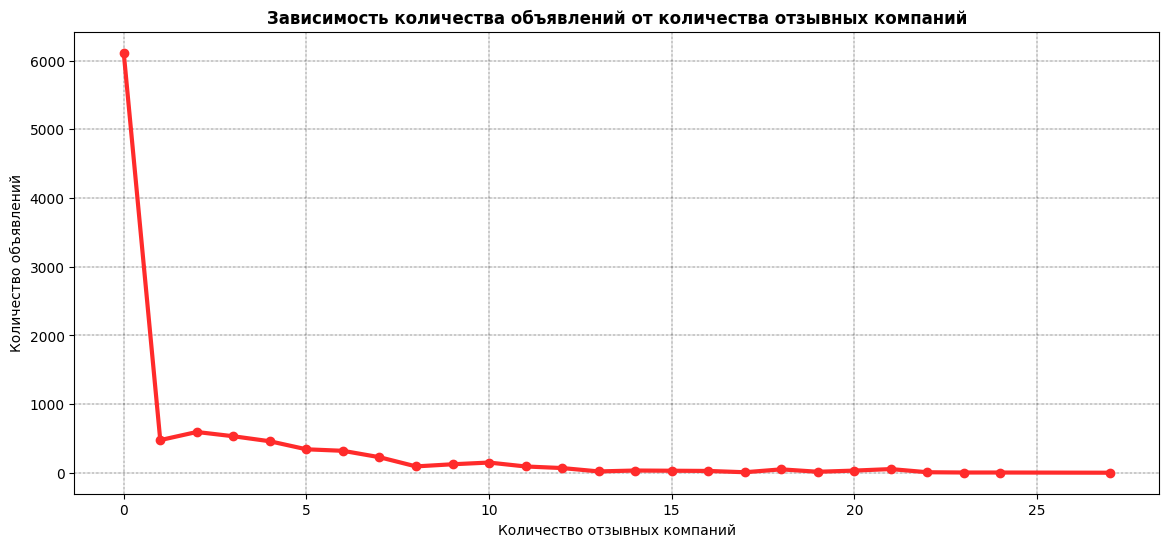

In [2648]:
plt.figure(figsize = (14, 6))
plt.plot(recalls_table.index, recalls_table, color = '#FF2B2B', linewidth = 3, marker = 'o')
plt.title('Зависимость количества объявлений от количества отзывных компаний', fontweight = 'bold')
plt.xlabel('Количество отзывных компаний')
plt.ylabel('Количество объявлений')
plt.grid(axis = 'both', color = 'black', linestyle = '-.', linewidth = 0.3)

Большинство автомобилей не имели отзывных компаний - по мере нарастания количества отзывных компаний, количество таких авто в датасете значительно уменьшается

5.complaints_count - количество жалоб на конкретную модель

In [2649]:
complaints_table = pd.cut(df['complaints_count'], bins = [0, 50, 100, 150, 200, 500, 1000, 2000, 3000, 4000, 6000],
    labels = ['до 50', '50 – 100', '100 – 150', '150 – 200', '200 – 500', '500 – 1000', '1000 - 2000', '2000 - 3000', '3000 - 4000', '4000+'])
complaints_table = complaints_table.value_counts().sort_index()

Text(0, 0.5, 'Количество автомобилей')

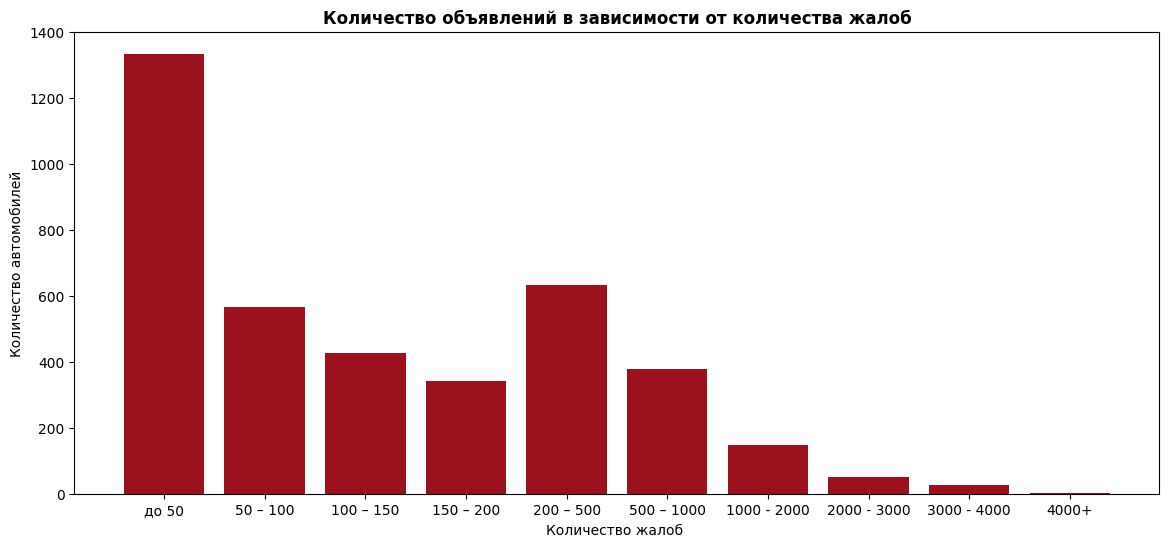

In [2650]:
plt.figure(figsize = (14, 6))
plt.bar(complaints_table.index, complaints_table, color = '#9B111E')


plt.title('Количество объявлений в зависимости от количества жалоб', fontweight = 'bold')
plt.xlabel('Количество жалоб ')
plt.ylabel('Количество автомобилей')

Наибольшее количество авто имеют небольшое количество жалоб - до 50. С увеличением количества жалоб в целом уменьшается количество объявлений, не считая резкого скачка на 200 - 500 жалоб

6.injuries - количесвтво травмы, полученные при использовании данной модели авто

7.deaths - колчество умерших, при использовании данной модели авто

Рассмотрим как выглядит распределение этих признаков

In [2651]:
injuries_table = df['injuries'].value_counts().sort_index()
deaths_table = df['deaths'].value_counts().sort_index()
deaths_table = np.log1p(deaths_table)
injuries_table = np.log1p(injuries_table)

Text(0.5, 0, 'Количество погибших')

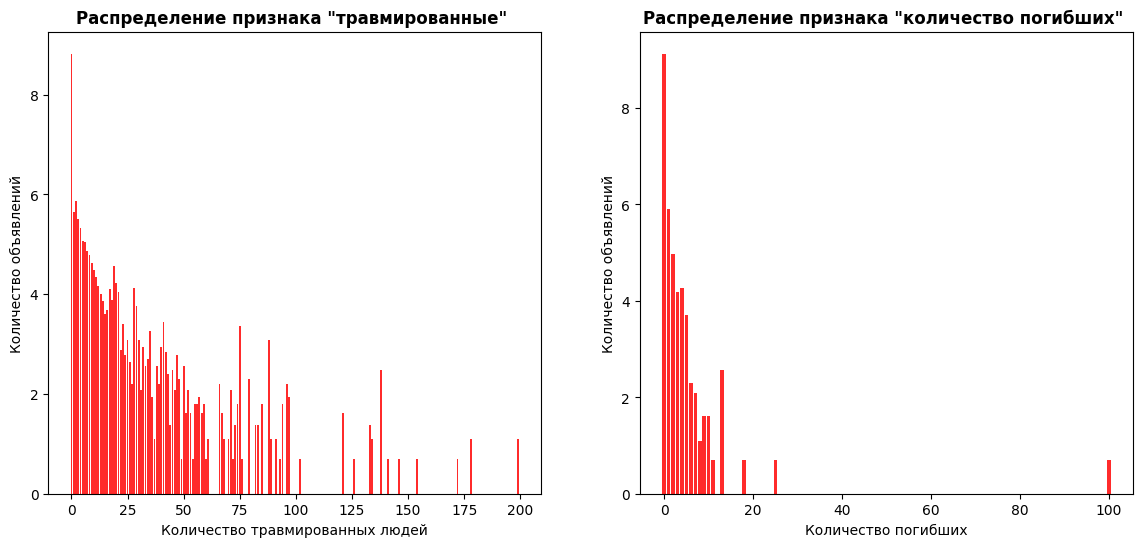

In [2652]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(injuries_table.index, injuries_table, color = '#FF2B2B')
plt.title('Распределение признака "травмированные" ', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Количество травмированных людей')

plt.subplot(1, 2, 2)
plt.bar(deaths_table.index, deaths_table, color = '#FF2B2B')
plt.title('Распределение признака "количество погибших" ', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Количество погибших')



Преимущественно в нашем датасете авто с неболшим количеством травмированных людей или погибших, с увеличением количества пострадавших количество объявлений значительно уменьшается. Но есть и явные выбросы

Теперь рассмотрим наши рейтинговые признаки

**10.overall_rating** - общий рейтинг безопасности авто

**11.front_crash_rating** - рейтинг безопасности авто при столкновении прямо

**12.side_crash_rating** - рейтинг безопасности авто при столкновении боком

**13.rollover_rating** - рейтинг безопасности авто при перевороте

In [2653]:
overall_rating_table = df['overall_rating'].value_counts().sort_index()
front_crash_rating_table = df['front_crash_rating'].value_counts().sort_index()
side_crash_rating_table = df['side_crash_rating'].value_counts().sort_index()
rollover_rating_table = df['rollover_rating'].value_counts().sort_index()

([<matplotlib.axis.XTick at 0x7de0ffc3b470>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

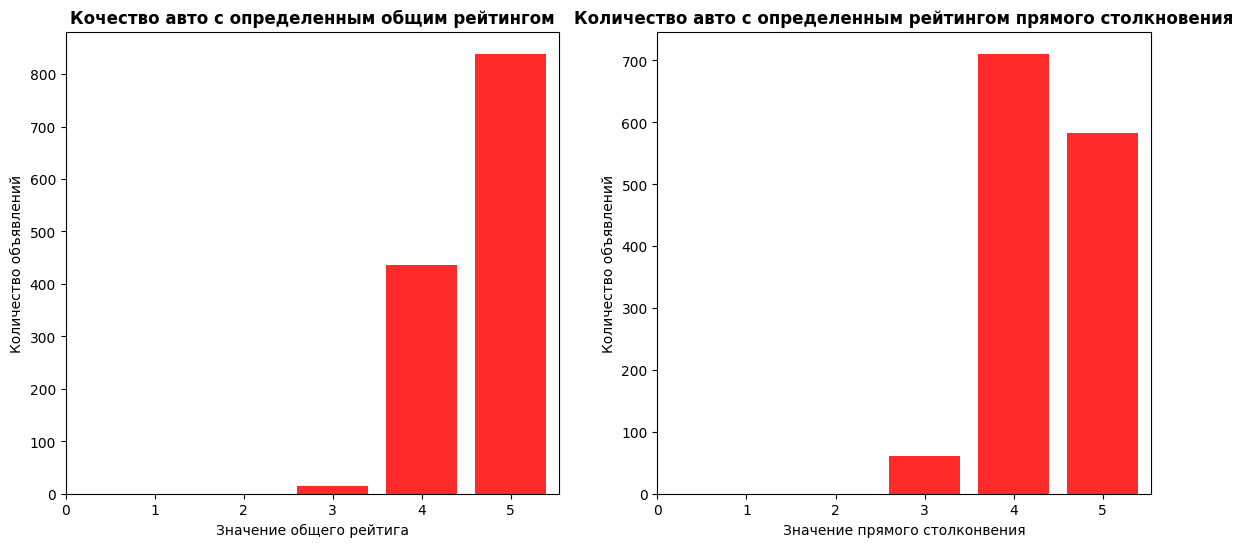

In [2654]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(overall_rating_table.index, overall_rating_table, color = '#FF2B2B')
plt.title('Кочество авто с определенным общим рейтингом', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение общего рейтига')
plt.xticks(range(0, 6))

plt.subplot(1, 2, 2)
plt.bar(front_crash_rating_table.index, front_crash_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным рейтингом прямого столкновения', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение прямого столконвения')
plt.xticks(range(0, 6))


([<matplotlib.axis.XTick at 0x7de0ffd06f90>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

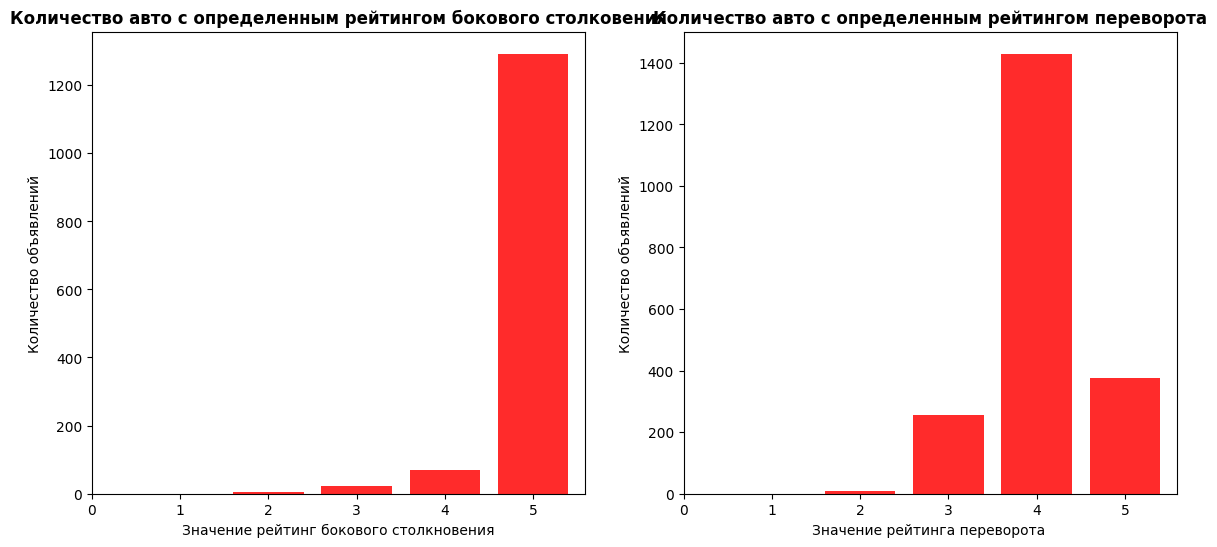

In [2655]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
plt.bar(side_crash_rating_table.index, side_crash_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным рейтингом бокового столковения', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение рейтинг бокового столкновения')
plt.xticks(range(0, 6))

plt.subplot(1, 2, 2)
plt.bar(rollover_rating_table.index, rollover_rating_table, color = '#FF2B2B')
plt.title('Количество авто с определенным рейтингом переворота', fontweight = 'bold')
plt.ylabel('Количество объявлений')
plt.xlabel('Значение рейтинга переворота ')
plt.xticks(range(0, 6))

В целом у нас в датасете представлены машины с хорошими значенями по столкновениям -  это объяснимо тем, что мы взяли популярные марки авто, которые уже достаточно долго на рынке, если бы у них были плохие показатели безопасности, то производители бы долго не продержалиь

14.manufacturer_country - страна выпуска модели автомобиля

Давайте посмотрим какое у нас распределение автомобилей по странам производства

In [2656]:
country_table = pd.pivot_table(df, values = 'url', index = 'manufacturer_country', aggfunc = 'count')
country_table

,url
manufacturer_country,
CHINA,301
GERMANY,1126
ITALY,10
JAPAN,213
MEXICO,176
SLOVAKIA,215
UNITED STATES (USA),2322


Text(0, 0.5, 'Количество автомобилей(объявлений)')

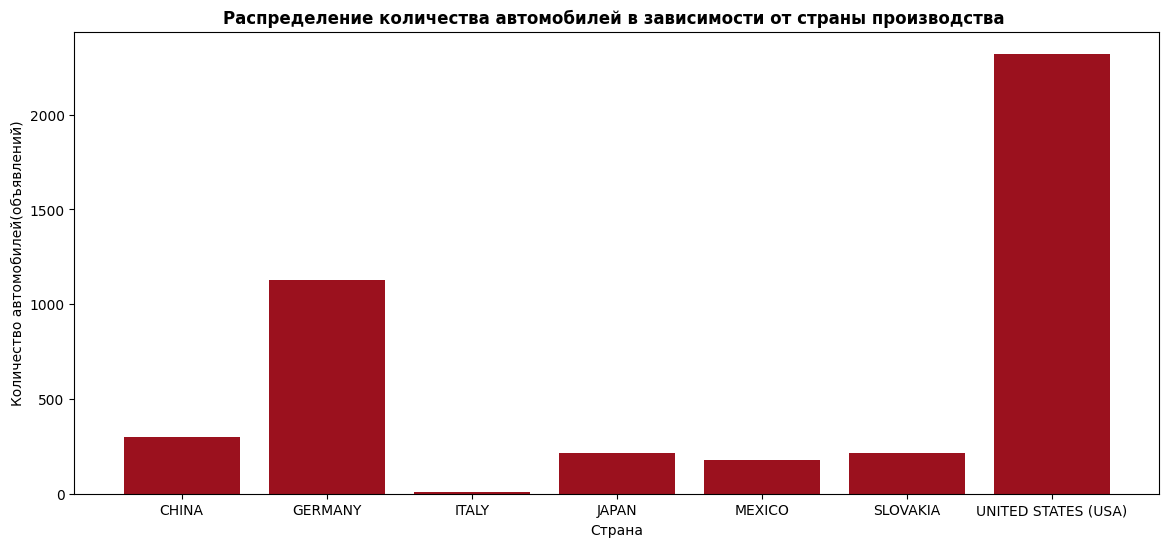

In [2657]:
plt.figure(figsize = (14, 6))
plt.bar(country_table.index, country_table['url'], color = '#9B111E')


plt.title('Распределение количества автомобилей в зависимости от страны производства ', fontweight = 'bold')
plt.xlabel('Страна')
plt.ylabel('Количество автомобилей(объявлений)')

Лидеры отрасли - США и Германия - у них производятся больше всего. Проигрывает Италия. Но сильно опираться на график пока нельзя - столбец содержит очень большое количество пропусков, заполнить которые невозможно, так как одна и та же марка может собирать свои модели в разных странах. Вероятно будем убирать этот признак

15.model_exists - маркер о существовании такой модели автомобиля. В нашем датасете если модели нет, то и информации по ней нет. Это исключительно технических столбец для апи, поэтому мы его удаляем

In [2658]:
df['model_exists'].unique()

array([False,  True])

16.title - заголовок объявления о продаже конкретного авто
это все заголовки, которые прописывает автор объявления при их создании, сожержит общую текстовую информацию об объявлении

In [2659]:
df['title'].sample(5)

,title
832,"Продажа Kia Rio, 2015 год в Сочи"
5568,Fiat Albea 2008 в Перми
8555,"Продажа Suzuki Jimny, 2014 год в Сочи"
3716,"Продажа Skoda Octavia, 2012 год в Вологде"
5409,Fiat Doblo 2008 в Екатеринбурге


17.city - город, в котором осуществляется продажа конкретного авто

In [2660]:
city_pivot = pd.pivot_table(df, values = 'url', index = 'city', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей(объявлений)')

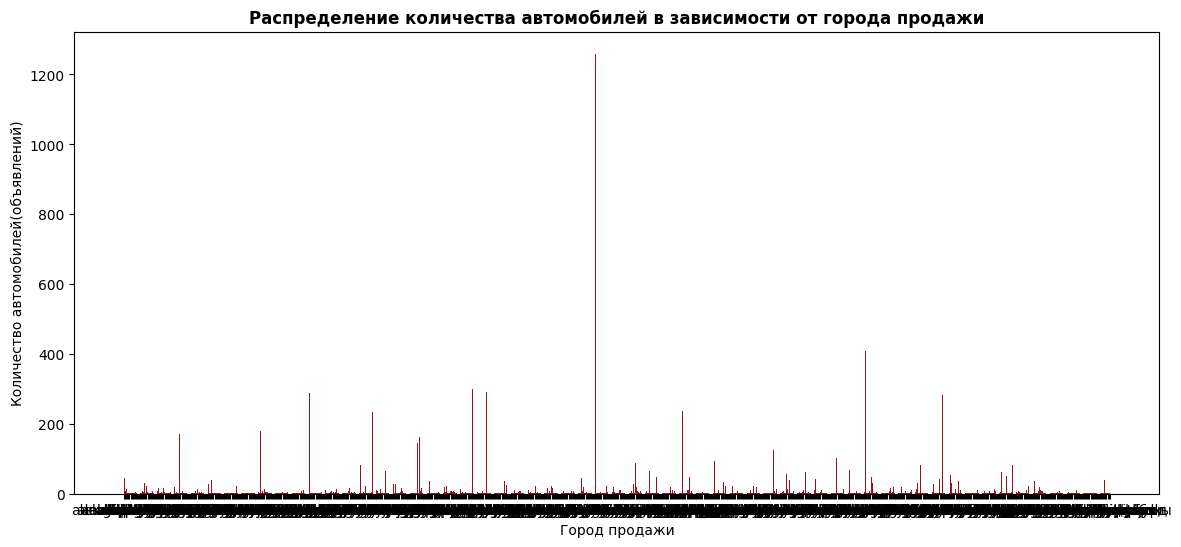

In [2661]:
plt.figure(figsize = (14, 6))
plt.bar(city_pivot.index, city_pivot['url'], color = '#9B111E')


plt.title('Распределение количества автомобилей в зависимости от города продажи', fontweight = 'bold')
plt.xlabel('Город продажи')
plt.ylabel('Количество автомобилей(объявлений)')

Ой, что-то огромное, давайте для наглядности возьмем 20 городов, с наибольшим количеством объявлений

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'nizhniy-novgorod'),
  Text(1, 0, 'perm'),
  Text(2, 0, 'surgut'),
  Text(3, 0, 'simferopol'),
  Text(4, 0, 'ufa'),
  Text(5, 0, 'rostov-na-donu'),
  Text(6, 0, 'kazan'),
  Text(7, 0, 'kemerovo'),
  Text(8, 0, 'barnaul'),
  Text(9, 0, 'chelyabinsk'),
  Text(10, 0, 'vladivostok'),
  Text(11, 0, 'irkutsk'),
  Text(12, 0, 'omsk'),
  Text(13, 0, 'tyumen'),
  Text(14, 0, 'ekaterinburg'),
  Text(15, 0, 'krasnoyarsk'),
  Text(16, 0, 'krasnodar'),
  Text(17, 0, 'spb'),
  Text(18, 0, 'novosibirsk'),
  Text(19, 0, 'moscow')])

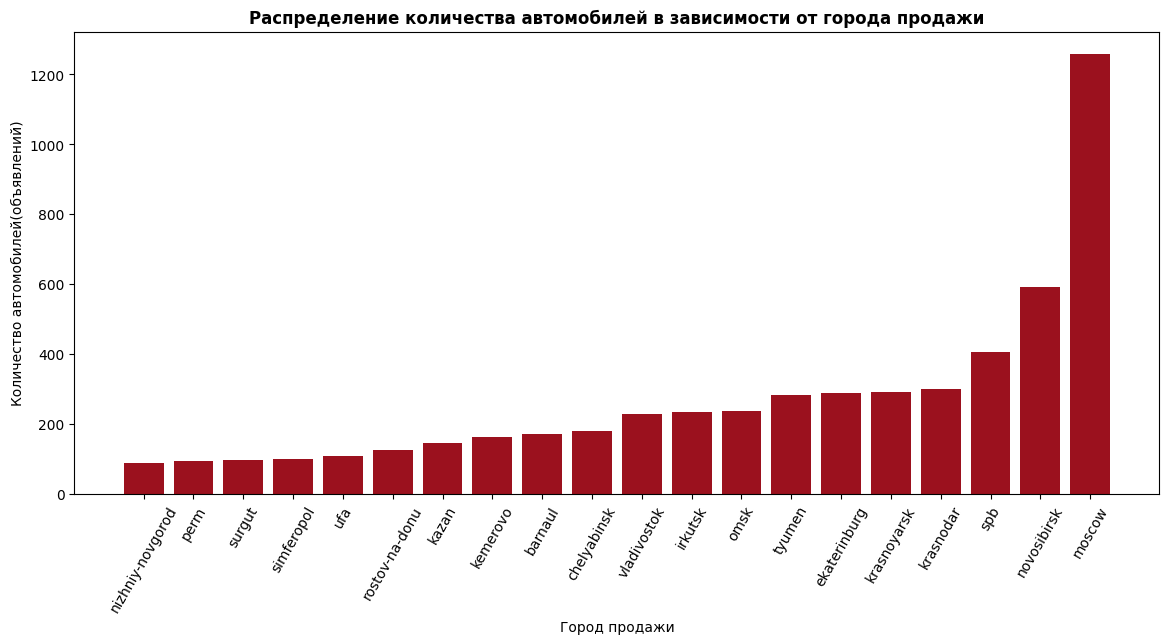

In [2662]:
city_pivot = city_pivot.sort_values(by = 'url').tail(20)
plt.figure(figsize = (14, 6))
plt.bar(city_pivot.index, city_pivot['url'], color = '#9B111E')

plt.title('Распределение количества автомобилей в зависимости от города продажи', fontweight = 'bold')
plt.xlabel('Город продажи')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 60)

В лидерах стоят города с топ-3 по населению. Поэтому у них и наибольшее количество объявлений

18.price - цена конкретного автомобиля

In [2663]:
price_table = pd.cut(df['price'], bins = [0, 500000, 1000000, 2000000, 4000000, 6000000, 10000000, 4000000000],
    labels = ['до 500.000', '500.000 – 1.000.000', '1.000.000 – 2.000.000', '2.000.000 – 4.000.000', '4.000.000 – 6.000.000',
              '6.000.000 – 10.000.000', '10.000.000+'])
price_table = price_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'до 500.000'),
  Text(1, 0, '500.000 – 1.000.000'),
  Text(2, 0, '1.000.000 – 2.000.000'),
  Text(3, 0, '2.000.000 – 4.000.000'),
  Text(4, 0, '4.000.000 – 6.000.000'),
  Text(5, 0, '6.000.000 – 10.000.000'),
  Text(6, 0, '10.000.000+')])

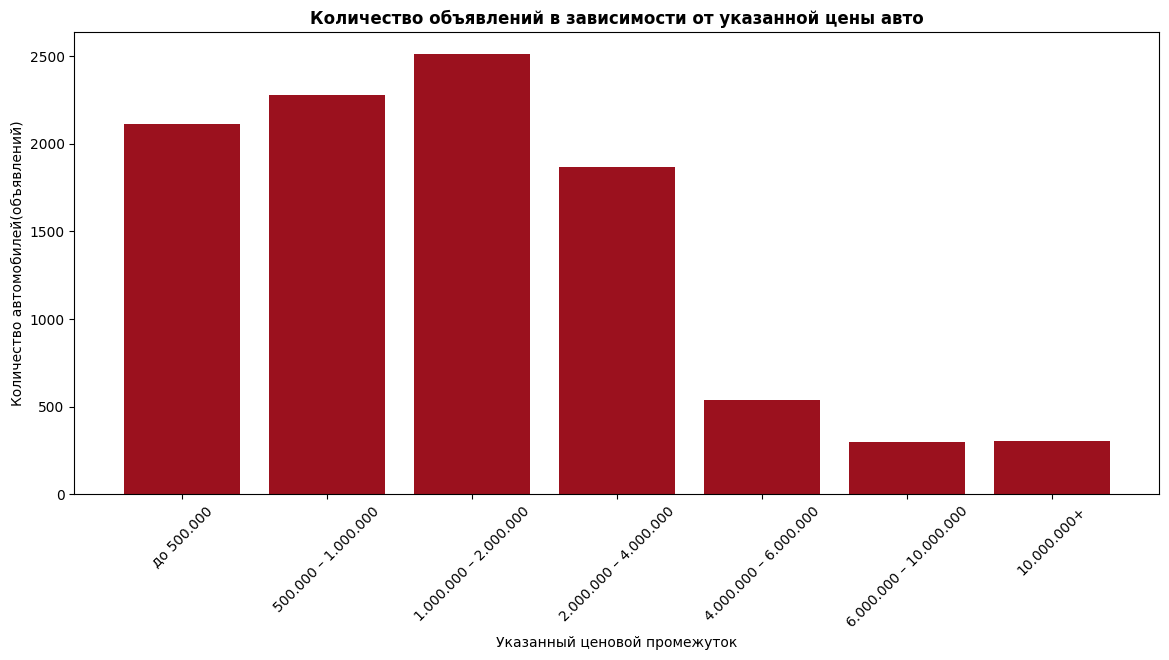

In [2664]:
plt.figure(figsize = (14, 6))
plt.bar(price_table.index, price_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от указанной цены авто', fontweight = 'bold')
plt.xlabel('Указанный ценовой промежуток')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Видим, что много бюджетного и среднего сегмента авто. Более дорогие модели встречаются гораздо меньше

19.engine - тип топлива, объем двигателя и дополнительное оборудование

In [2665]:
df['engine'].unique()

array(['бензин, 2.0 л', 'бензин, 1.5 л', 'бензин, 1.6 л', 'бензин, 3.8 л',
       'бензин, 2.5 л', 'бензин, 1.8 л, гибрид', 'дизель, 2.2 л',
       'бензин, 3.0 л', 'бензин, 1.4 л', 'дизель, 4.0 л', 'бензин, 2.4 л',
       'бензин, 3.5 л', 'бензин, 1.8 л', 'дизель, 2.5 л', 'бензин, 2.7 л',
       'дизель, 2.8 л', 'бензин, 2.5 л, ГБО', 'дизель, 4.5 л',
       'дизель, 3.0 л', 'дизель, 2.0 л', 'дизель, 1.6 л', 'бензин, 1.3 л',
       'бензин, 1.5 л, ГБО', 'бензин, 1.3 л, ГБО', 'бензин, 1.0 л',
       'бензин, 2.0 л, ГБО', 'бензин, 1.6 л, ГБО', 'бензин, 4.6 л',
       'бензин, 2.4 л, гибрид, ГБО', '1.8 л', 'бензин, 5.0 л',
       'бензин, 2.5 л, гибрид', 'бензин, 1.8 л, ГБО',
       'бензин, 2.4 л, гибрид', 'бензин, 1.6 л, гибрид', 'бензин, 1.2 л',
       'дизель, 4.2 л', 'бензин, 1.4 л, ГБО', 'бензин, 3.4 л',
       'дизель, 1.7 л', '2.0 л', nan, 'бензин, 3.5 л, гибрид',
       'бензин, 4.0 л', 'бензин, 2.4 л, ГБО', 'бензин, 1.1 л',
       'бензин, 4.7 л', 'бензин, 2.0 л, гибрид', 'бензи

Тип топлива принимает значения: бензин, дизель, электро
Также есть дополнительное оборудование машины в виде ГБО

Этот столбец будет через некоторое время трансформироваться в несколько новых признаков

20.transmission - тип коробки передач у конкретного автомобиля


In [2666]:
transmission_table = pd.pivot_table(df, values = 'url', index = 'transmission', aggfunc = 'count')

Text(0, 0.5, 'Количество автомобилей(объявлений)')

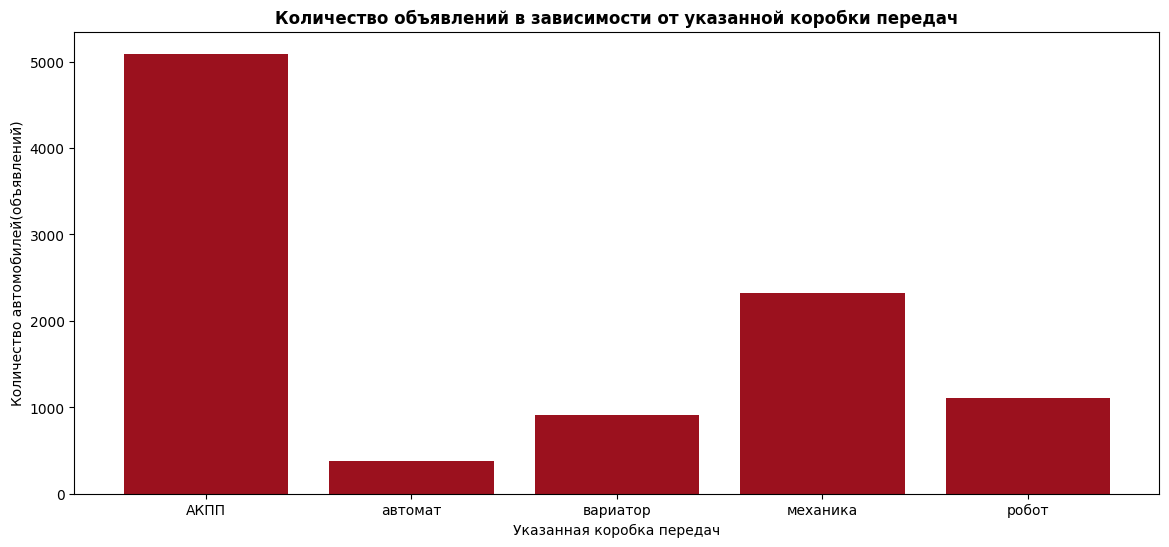

In [2667]:
plt.figure(figsize = (14, 6))
plt.bar(transmission_table.index, transmission_table['url'], color = '#9B111E')

plt.title('Количество объявлений в зависимости от указанной коробки передач', fontweight = 'bold')
plt.xlabel('Указанная коробка передач')
plt.ylabel('Количество автомобилей(объявлений)')

АКПП и автомат - это одно и то же, поэтому заменим все значения "автомат" на "АКПП"
НУ И КОНЕЧНО КАКОЙ-ТО ТЕКСТИК

In [2668]:
df.loc[df['transmission'] == 'автомат', 'transmission'] = 'АКПП'

In [2669]:
pd.pivot_table(df, values = 'url', index = 'transmission', aggfunc = 'count')

,url
transmission,
АКПП,5474
вариатор,913
механика,2326
робот,1103


теперь все супер!

21.mileage - пробег конкретного автомобилят, измеряется в километрах

Посмотрим на распределение пробега,

In [2670]:
df['mileage'].min()

1.0

In [2671]:
df['mileage'].max()

999999.0

In [2672]:
mileage_table = pd.cut(df['mileage'], bins = [0, 10000, 30000, 50000, 100000, 150000, 200000, 300000, 400000, 600000, 1000000],
    labels = ['до 10.000', '10.000 - 30.000', '30.000 - 50.000', '50.000 – 100.000', '100.000 – 150.000', '150.000 – 200.000', '200.000 – 300.000',
              '300.000 – 400.000', '400.000 - 600.000', '600000+'])
mileage_table = mileage_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'до 10.000'),
  Text(1, 0, '10.000 - 30.000'),
  Text(2, 0, '30.000 - 50.000'),
  Text(3, 0, '50.000 – 100.000'),
  Text(4, 0, '100.000 – 150.000'),
  Text(5, 0, '150.000 – 200.000'),
  Text(6, 0, '200.000 – 300.000'),
  Text(7, 0, '300.000 – 400.000'),
  Text(8, 0, '400.000 - 600.000'),
  Text(9, 0, '600000+')])

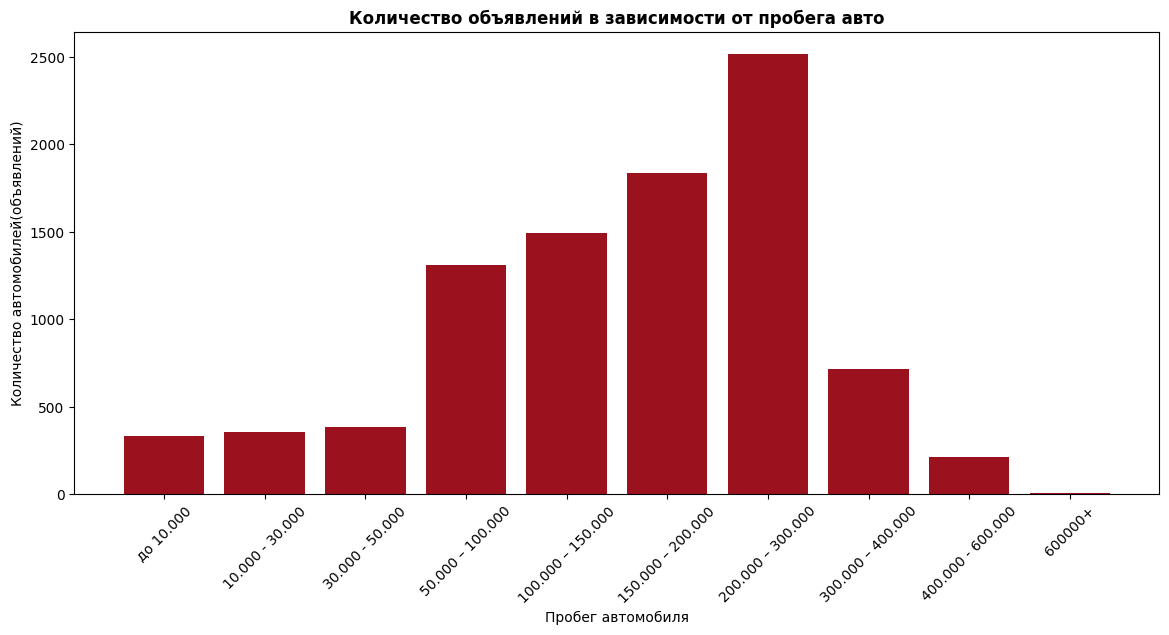

In [2673]:
plt.figure(figsize = (14, 6))
plt.bar(mileage_table.index, mileage_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от пробега авто', fontweight = 'bold')
plt.xlabel('Пробег автомобиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Редко продаются совсем новые, с минимальным пробегом, или же уже сильно повидавшие автомобили. В основном люди продают с пробегом от 50.000 до 300.000 С

Явно выделяются количесвто машин с пробегом 200.000 - 300.000

22.drive - тип привода конкретного автомобиля

In [2674]:
df[df['drive'] == 'полный'].index

Index([4, 9, 11, 15, 16, 20, 38, 39, 44, 47, 55], dtype='int64')

In [2675]:
i = [4, 9, 11, 15, 16, 20, 38, 39, 44, 47, 55]

df.loc[i, 'drive'] = '4WD'

In [2676]:
drive_pivot = pd.pivot_table(df, values = 'url', index = 'drive', aggfunc = 'count')

([0, 1, 2], [Text(0, 0, '4WD'), Text(1, 0, 'задний'), Text(2, 0, 'передний')])

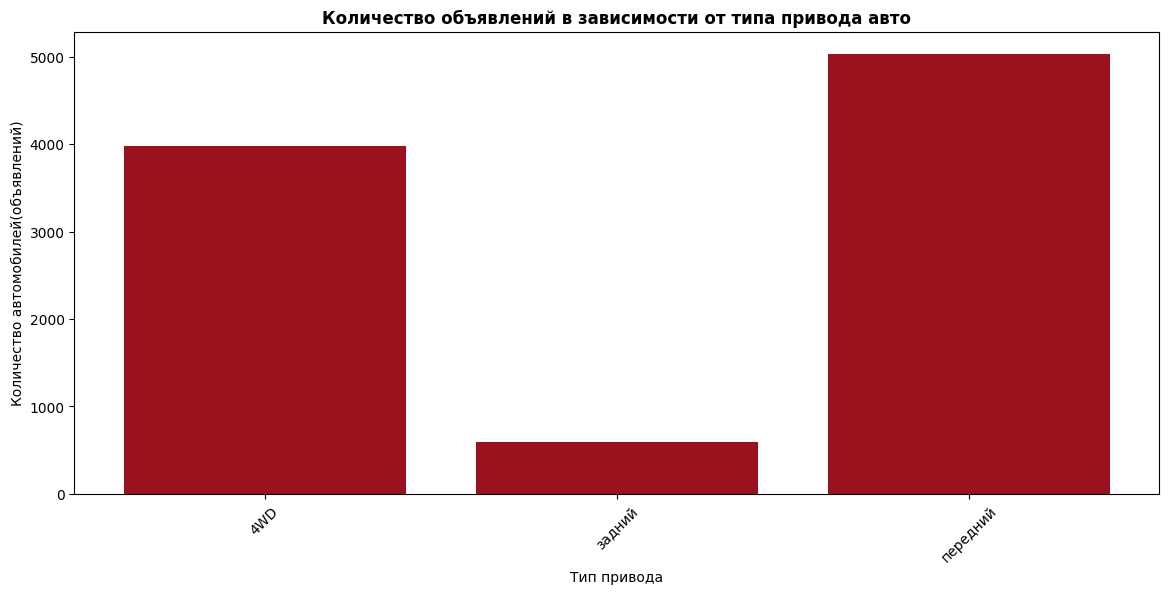

In [2677]:
plt.figure(figsize = (14, 6))
plt.bar(drive_pivot.index, drive_pivot['url'], color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа привода авто', fontweight = 'bold')
plt.xlabel('Тип привода')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Чаше всего встречается передний привод, это почти у половины машин из датасета. Полный привод также часто встречается, около 4.000 объявлений. Явно реже наблюдаются машины с задним приводом

23.body - тип кузова конкретного автомобиля

In [2678]:
body_table = df['body'].value_counts()
body_table

,count
body,
седан,1994
хэтчбек 5 дв.,885
джип/suv 5 дв.,544
лифтбек,348
универсал,326
хэтчбек 3 дв.,178
купе,90
джип/suv 3 дв.,65
пикап,23


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'седан'),
  Text(1, 0, 'хэтчбек 5 дв.'),
  Text(2, 0, 'джип/suv 5 дв.'),
  Text(3, 0, 'лифтбек'),
  Text(4, 0, 'универсал'),
  Text(5, 0, 'хэтчбек 3 дв.'),
  Text(6, 0, 'купе'),
  Text(7, 0, 'джип/suv 3 дв.'),
  Text(8, 0, 'пикап'),
  Text(9, 0, 'минивэн'),
  Text(10, 0, 'открытый'),
  Text(11, 0, 'хэтчбэк'),
  Text(12, 0, 'внедорожник или кроссовер')])

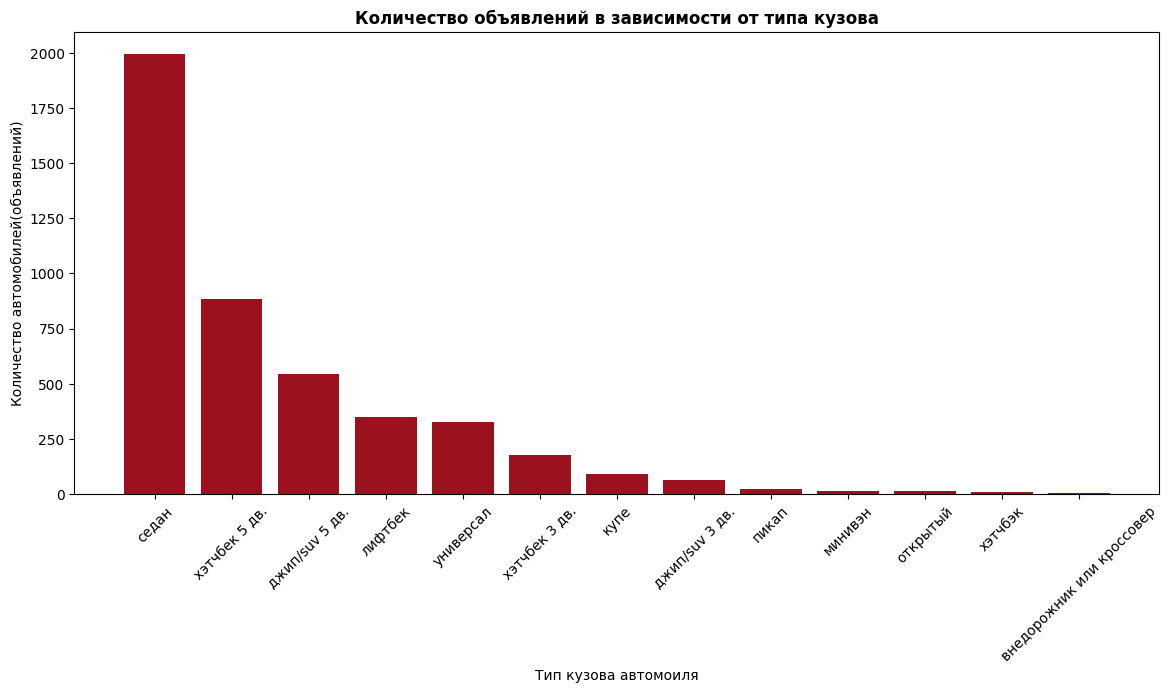

In [2679]:
plt.figure(figsize = (14, 6))
plt.bar(body_table.index, body_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа кузова', fontweight = 'bold')
plt.xlabel('Тип кузова автомоиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Чаще всего встречаются седаны и пятидверные хэтчбэки - в целом, это самые обыяные автомобили, поэтому их и больше. Пикапы, минивэны, октрытые авто и внедорожники встречаются гораздо реже

24.color - цвет конкретного автомобиля

In [2688]:
df[df['color'] == 'серебряный'].index

Index([23, 30], dtype='int64')

In [2692]:
i = [23, 30]

df.loc[i, 'color'] = 'серебристый'

In [2693]:
color_table = df['color'].value_counts()
color_table

,count
color,
черный,2331
белый,2083
серый,1589
синий,878
серебристый,810
красный,502
зеленый,299
коричневый,281
голубой,136


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'черный'),
  Text(1, 0, 'белый'),
  Text(2, 0, 'серый'),
  Text(3, 0, 'синий'),
  Text(4, 0, 'серебристый'),
  Text(5, 0, 'красный'),
  Text(6, 0, 'зеленый'),
  Text(7, 0, 'коричневый'),
  Text(8, 0, 'голубой'),
  Text(9, 0, 'бежевый'),
  Text(10, 0, 'бордовый'),
  Text(11, 0, 'оранжевый'),
  Text(12, 0, 'золотистый'),
  Text(13, 0, 'фиолетовый'),
  Text(14, 0, 'желтый'),
  Text(15, 0, 'розовый')])

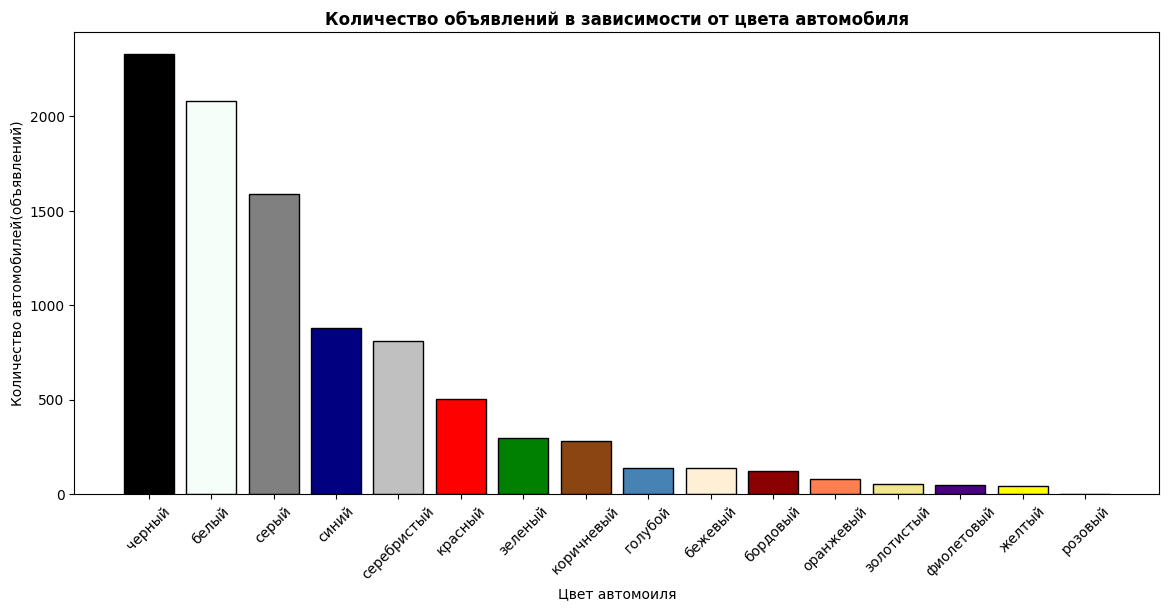

In [2702]:
plt.figure(figsize = (14, 6))
plt.bar(color_table.index, color_table, color = ['#000000', '#F5FFFA', '#808080', '#000080', '#C0C0C0', '#FF0000', '#008000',
                                                '#8B4513', '#4682B4',  '#FFEFD5', '#8B0000', '#FF7F50', '#F0E68C', '#4B0082',
                                                '#FFFF00', '#FF69B4'], edgecolor = 'black', linewidth = 1)

plt.title('Количество объявлений в зависимости от цвета автомобиля', fontweight = 'bold')
plt.xlabel('Цвет автомоиля')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Люди приобретают чаще базовые цвета атвтомобилей, отдавая наибольшее предпочтение черному, белому и серому. Сильно реже наблюдаются необычные цвета: розовый, желтый, фиолетовый и так далее

25.wheel - расположение руля в конкретном автомобиле

In [2703]:
wheel_table = df['wheel'].value_counts()
wheel_table

,count
wheel,
левый,8322
правый,1157


Text(0.5, 1.0, 'Количество автомобилей в зависимости от расположения руля')

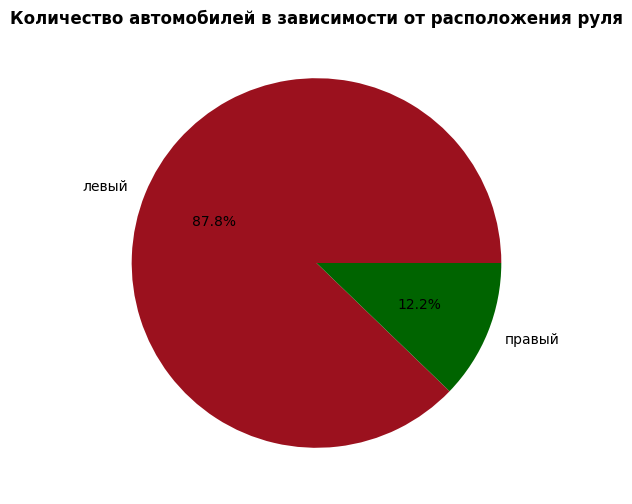

In [2704]:
plt.figure(figsize = (14, 6))
colors = ['#9B111E', '#006400']
plt.pie(wheel_table, labels = wheel_table.index, colors = colors, autopct = '%.1f%%')
plt.title('Количество автомобилей в зависимости от расположения руля', fontweight = 'bold')

Чаще встречаем леворульные авто, это из-за того, что брали российский рынок, а у нас как раз леворульное движение

26.hp - количество лошадиных сил конкретного автомобиля

In [2705]:
gp_table = pd.cut(df['hp'], bins = [0, 80, 110, 156, 200, 252, 300, 500, 2000],
    labels = ['до 80', '80 - 110', '110 - 156', '156 - 200', '200 – 252', '252 - 300', '300 - 500',
              '500+'])
gp_table = gp_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'до 80'),
  Text(1, 0, '80 - 110'),
  Text(2, 0, '110 - 156'),
  Text(3, 0, '156 - 200'),
  Text(4, 0, '200 – 252'),
  Text(5, 0, '252 - 300'),
  Text(6, 0, '300 - 500'),
  Text(7, 0, '500+')])

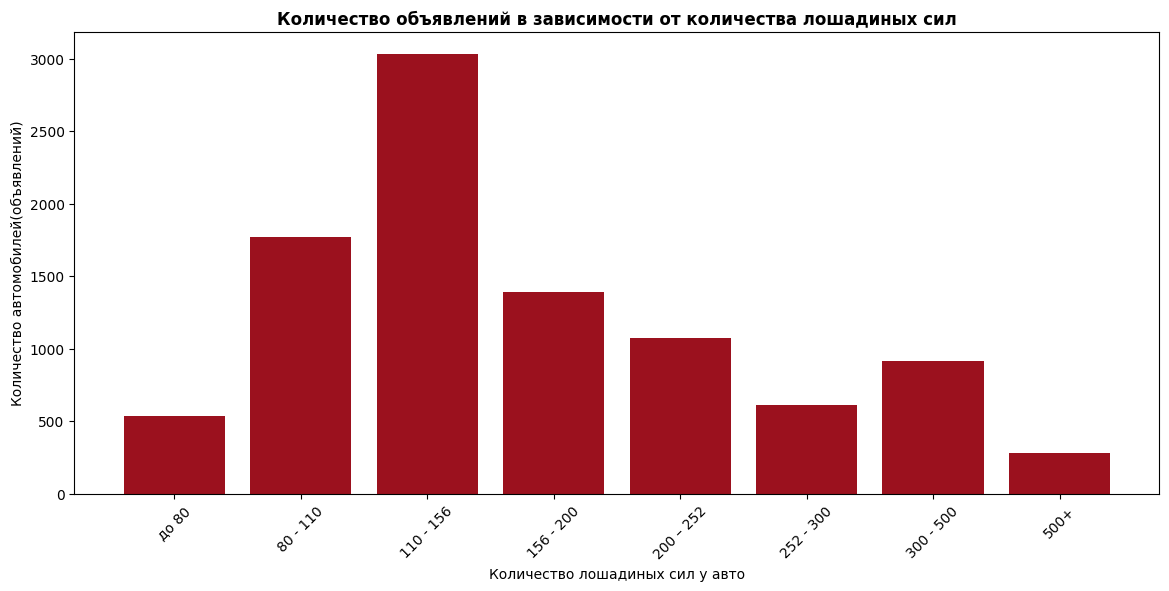

In [2706]:
plt.figure(figsize = (14, 6))
plt.bar(gp_table.index, gp_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от количества лошадиных сил', fontweight = 'bold')
plt.xlabel('Количество лошадиных сил у авто')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

Большинство значений находится в промеждутке от 80 до 200 логадиных сил. Пик достигается в группе 110 - 156

**28. marketcheck_avg_price** - средня цена по рынку на эту модель этого года. $


In [2707]:
price_avg_table = df['marketcheck_avg_price'].value_counts().sort_index()
price_avg_table

,count
marketcheck_avg_price,
990.00,1
1250.00,2
1800.00,2
1990.00,2
1999.00,1
...,...
128711.61,2
129441.54,5
139404.35,1


In [2708]:
price_avg_table = pd.cut(df['marketcheck_avg_price'], bins = [0, 1000, 5000, 10000, 50000, 1500000, 3000000, 1000000000],
    labels = ['до 1000$', '1000$ - 5000$', '5000$ - 10000$', '10000$ - 50000$', '50000$ – 1500000$',
              '1500000$ - 3000000$', '3000000$+'])
price_avg_table = price_avg_table.value_counts().sort_index()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'до 1000$'),
  Text(1, 0, '1000$ - 5000$'),
  Text(2, 0, '5000$ - 10000$'),
  Text(3, 0, '10000$ - 50000$'),
  Text(4, 0, '50000$ – 1500000$'),
  Text(5, 0, '1500000$ - 3000000$'),
  Text(6, 0, '3000000$+')])

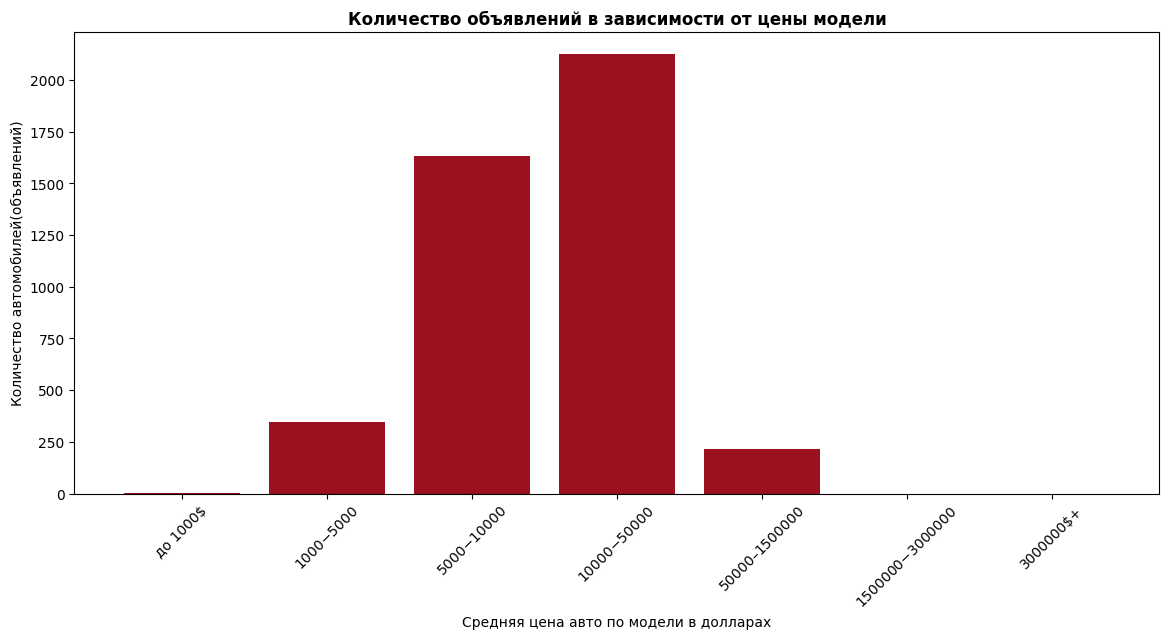

In [2709]:
plt.figure(figsize = (14, 6))
plt.bar(price_avg_table.index, price_avg_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от цены модели', fontweight = 'bold')
plt.xlabel('Средняя цена авто по модели в долларах')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)

В целом машины из нашего датасета на американском рынке оценены от 5.000$ до 50.000$

29. marketcheck_avg_days_on_market - среднее количество дней сколько висит объявление

In [2711]:
market_table = df['marketcheck_avg_days_on_market'].value_counts().sort_index()
market_table

,count
marketcheck_avg_days_on_market,
10.00,4
19.93,3
21.00,1
22.09,7
25.65,1
...,...
1327.00,3
1336.92,1
1539.50,3


Text(0, 0.5, 'Количество автомобилей(объявлений)')

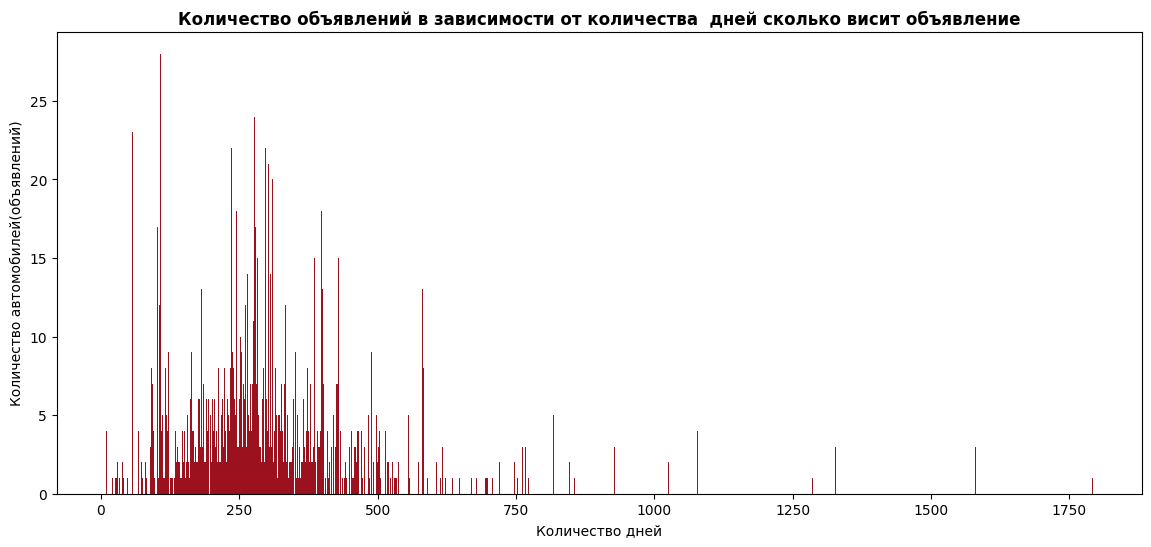

In [2712]:
plt.figure(figsize = (14, 6))
plt.bar(market_table.index, market_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от количества  дней сколько висит объявление', fontweight = 'bold')
plt.xlabel('Количество дней')
plt.ylabel('Количество автомобилей(объявлений)')

Объявления висят на площадках очень разное количество дней, отследить какую-то зависимость невозможно. Иногда люди забывают снимать объявления после продажи, это может сильно влиять и смещать нам распределение

**30. marketcheck_popularity_score** - оценка популярности авто на рынке

In [2713]:
score_table = df['marketcheck_popularity_score'].value_counts().sort_index()
score_table

,count
marketcheck_popularity_score,
0.0,5540
1.0,59
2.0,77
3.0,36
4.0,26
...,...
8762.0,3
13824.0,1
18109.0,1


([0, 1, 2],
 [Text(0, 0, 'Низкая популярность'),
  Text(1, 0, 'Средняя популярность'),
  Text(2, 0, 'Высокая популярность')])

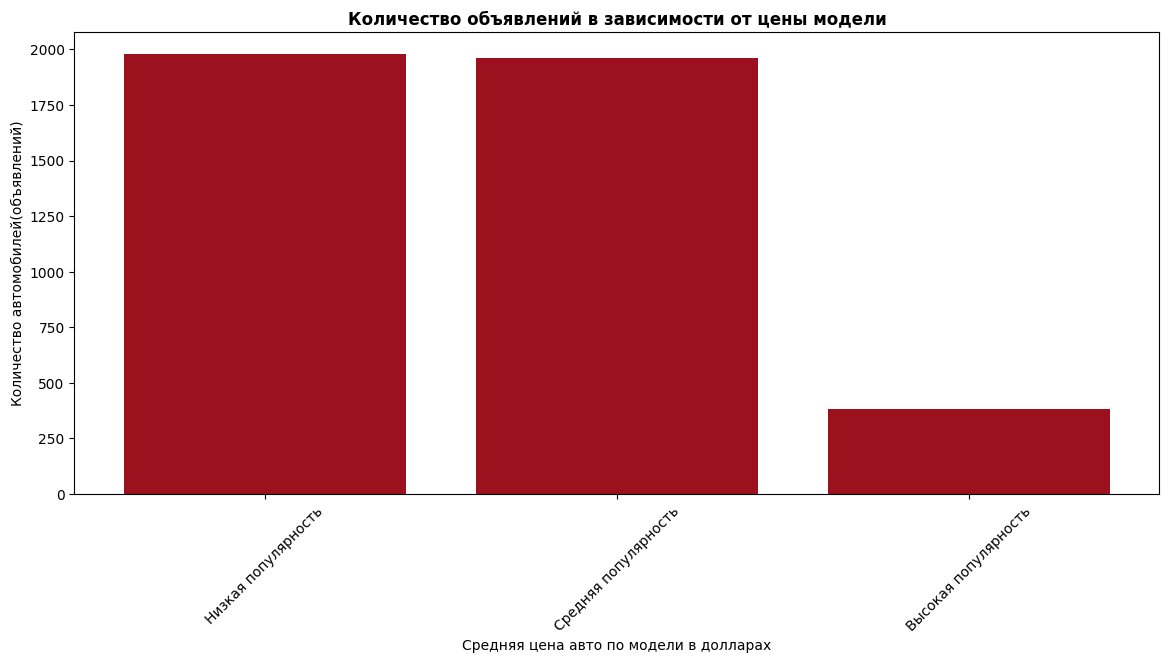

In [2714]:
score_table = pd.cut(df['marketcheck_avg_price'], bins = [0, 10000, 34000, 10000000],
    labels = ['Низкая популярность', 'Средняя популярность', 'Высокая популярность'])
score_table = score_table.value_counts().sort_index()


plt.figure(figsize = (14, 6))
plt.bar(score_table.index, score_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от цены модели', fontweight = 'bold')
plt.xlabel('Средняя цена авто по модели в долларах')
plt.ylabel('Количество автомобилей(объявлений)')
plt.xticks(rotation = 45)


Из-за того, что пропуски помечены нулями, то распределение стянулось к низкой популяргости. Будем смотреть на эту переменную после обработки пропусков и корректровки значений

# Feature Engineering и корректировка значений

Сначала поработаем со столбцом engine. Вычленим из него два признака - это тип топлива и объем двигателя. Дополнительное оборудование в виде ГБО не будем включать в наш анализ


После поработаем с признаком пробега. Пока там существуют проспуски. Но в случае с машинами 2025 и 2026 года выпуска пропуски это не отсутсвие значения (NaN), а скорее отсутсвие пробега у авто. Так что у таких авто мы заменим нан на 0

In [2715]:
df['engine'].sample(3)

,engine
137,"дизель, 4.5 л"
6171,"бензин, 2.0 л, гибрид"
7416,"бензин, 2.0 л"


In [2716]:
split_engine = df['engine'].str.split(',', expand = True)
split_engine.sample(4)

,0,1,2,3
9511,бензин,2.4 л,None,None
6665,бензин,2.0 л,None,None
7103,бензин,2.0 л,None,None
2681,бензин,4.8 л,ГБО,None


In [2717]:
df['oil_type'] = split_engine[0]
df['oil_type'].sample(5)

,oil_type
4978,бензин
4901,бензин
8728,бензин
9897,бензин
6633,бензин


In [2718]:
df['engine_volume'] = split_engine[1]
df['engine_volume'].sample(5)

,engine_volume
933,1.8 л
8815,2.0 л
4087,1.3 л
5630,1.4 л
6234,1.2 л


In [2719]:
df.head(2)

,url,make,model,year,recalls_count,complaints_count,injuries,deaths,has_fire,has_crash,...,transmission,mileage,drive,body,color,wheel,hp,description,oil_type,engine_volume
0,https://auto.drom.ru/ekaterinburg/toyota/crown...,toyota,crown,1990,0,0,0,0,0,0,...,АКПП,280000.0,задний,седан,синий,правый,170.0,: Если машина интересна и готовы взять её под ...,бензин,2.0 л
1,https://auto.drom.ru/perm/hyundai/elantra/4754...,hyundai,elantra,2020,3,224,15,2,6,20,...,АКПП,88000.0,передний,седан,серый,левый,150.0,: Федеральная сеть автосалонов Crystal Motors ...,бензин,2.0 л


In [2720]:
df = df.drop('engine', axis = 1)

In [2721]:
oil_table = df['oil_type'].value_counts()
oil_table

,count
oil_type,
бензин,8400
дизель,910
электро,494
инжектор,45
2.0 л,6
110 000 ₽,5
1.8 л,4
1.6 л,3
120 000 ₽,2


Удалим ненужные строки, так как у них все равно пропуски в типе топлива

In [2722]:
df.shape

(9904, 34)

In [2724]:
df = df[df['oil_type'].isin(['бензин', 'дизель', 'электро'])]

In [2725]:
oil_table = df['oil_type'].value_counts()
oil_table

,count
oil_type,
бензин,8400
дизель,910
электро,494


Text(0, 0.5, 'Количество автомобилей(объявлений)')

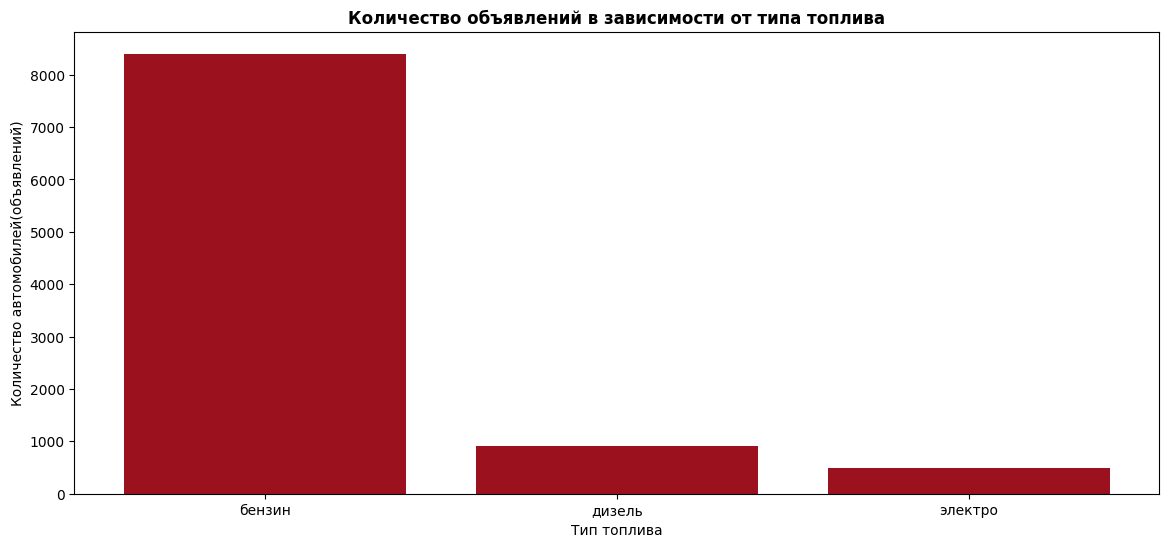

In [2726]:
plt.figure(figsize = (14, 6))
plt.bar(oil_table.index, oil_table, color = '#9B111E')

plt.title('Количество объявлений в зависимости от типа топлива', fontweight = 'bold')
plt.xlabel('Тип топлива')
plt.ylabel('Количество автомобилей(объявлений)')

Преимущественно на рынке бензиновые автомобили, остальные пользуются популярностью значительно меньше

In [2727]:
volume_table = df['engine_volume'].value_counts().sort_index()
volume_table

,count
engine_volume,
0.18 л.,1
0.5 л,1
0.7 л,57
0.8 л,4
0.9 л,4
...,...
6.2 л,126
6.4 л,19
6.7 л,2


In [2728]:
df = df.drop(df[df['engine_volume'] == ' ГБО'].index)

In [2732]:
df = df.drop(df[df['engine_volume'] == ' 0.18 л.'].index) # что-то очень странное, у авто не может такого маленького быть объема

In [2733]:
df['engine_volume'] = df['engine_volume'].str.strip().str[:3].astype(float)

AttributeError: Can only use .str accessor with string values!

In [2734]:
volume_table = df['engine_volume'].value_counts().sort_index()
volume_table

,count
engine_volume,
0.5,1
0.7,57
0.8,4
0.9,4
1.0,32
1.1,10
1.2,215
1.3,155
1.4,678


Text(0, 0.5, 'Количество автомобилей(объявлений)')

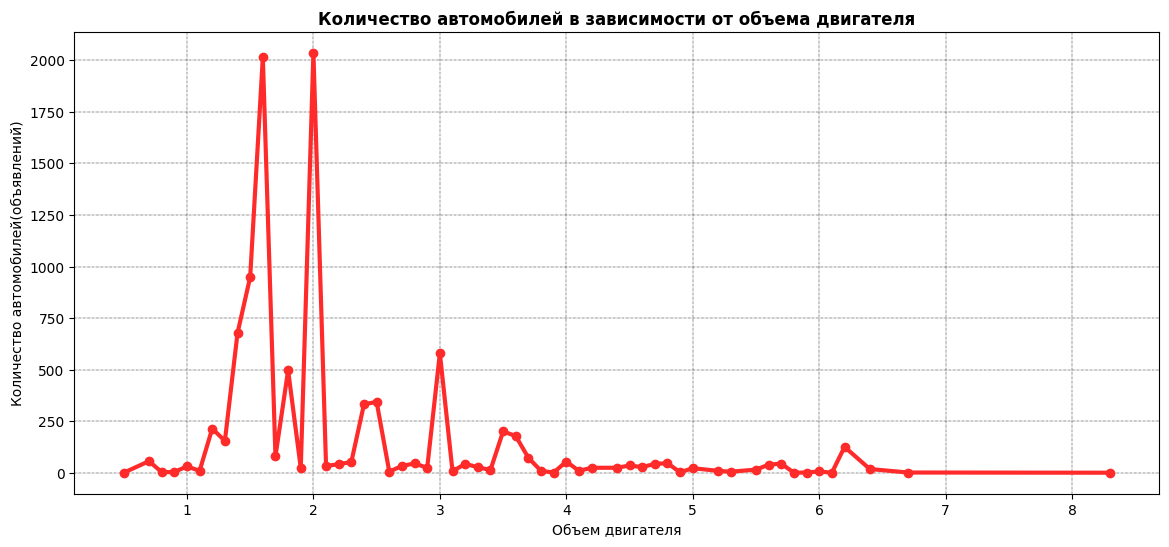

In [2735]:
plt.figure(figsize = (14, 6))

plt.plot(volume_table.index, volume_table, color = '#FF2B2B', linewidth = 3, marker = 'o')
plt.grid(axis = 'both', color = 'black', linestyle = '-.', linewidth = 0.3)
plt.title('Количество автомобилей в зависимости от объема двигателя', fontweight = 'bold')
plt.xlabel('Объем двигателя')
plt.ylabel('Количество автомобилей(объявлений)')

КАКОЙ-ТО ТЕКСТИК

Теперь у машин 2025 и 2026 года поменяем нан в пробеге на ноль

In [2736]:
print('Авто 2025 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2025)].shape)
print('Авто 2026 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2026)].shape)

Авто 2025 года выпуска без пробега (388, 34)
Авто 2026 года выпуска без пробега (157, 34)


In [2737]:
df.loc[(df['mileage'].isnull()) & (df['year'] == 2025), 'mileage'] = 0.0
df.loc[(df['mileage'].isnull()) & (df['year'] == 2026), 'mileage'] = 0.0

In [2738]:
print('Авто 2025 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2025)].shape)
print('Авто 2026 года выпуска без пробега', df[(df['mileage'].isnull()) & (df['year'] == 2026)].shape)

Авто 2025 года выпуска без пробега (0, 34)
Авто 2026 года выпуска без пробега (0, 34)


Теперь все должно быть отлично. Давайте перейдем к трудоемкому, но очень важному этапу

# Обработка пропусков в датасете

сразу давайте удалим ненужный нам признак model_exists

In [2739]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2740]:
df = df.dropna(subset = 'transmission')

In [2741]:
df.shape

(9771, 34)

In [2742]:
df = df.dropna(subset = 'mileage')

In [2743]:
df = df.dropna(subset = 'wheel')

In [2744]:
df = df.dropna(subset = 'drive')

In [2745]:
df = df.dropna(subset = 'hp')

In [2746]:
df = df.dropna(subset = 'color')

In [2747]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


Заполняем медианой по марке и модели пропущенные значение engine_volume

In [2748]:
median_by_mm = (df.groupby(['make'])['engine_volume'].median())

In [2749]:
mask = df['engine_volume'].isnull()
mask

,engine_volume
0,False
1,False
2,False
3,False
5,False
...,...
10008,False
10009,False
10010,False
10011,False


In [2750]:
df.loc[mask, 'engine_volume'] = (df.loc[mask, ['make']].apply(lambda row: median_by_mm[row['make']], axis = 1))

In [2751]:
df['engine_volume'].isnull().sum()

np.int64(230)

In [2752]:
df = df.dropna(subset = 'engine_volume')

In [2753]:
df.shape

(8834, 34)

In [2754]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2755]:
mode_table = df.groupby('make')['body'].value_counts()
mode_table = mode_table.groupby('make').head(1).reset_index()
mode_table

,make,body,count
0,audi,седан,109
1,bmw,седан,101
2,cadillac,джип/suv 5 дв.,124
3,chery,седан,2
4,chevrolet,седан,69
5,citroen,хэтчбек 5 дв.,53
6,dodge,седан,35
7,fiat,хэтчбек 5 дв.,41
8,ford,седан,107
9,geely,седан,15


In [2756]:
df = df.merge(mode_table[['make', 'body']], on = 'make', how = 'left', suffixes = ('', '_moda'))
df.loc[df['body'].isnull(), 'body'] = df.loc[df['body'].isnull(), 'body_moda']
df = df.drop(columns = 'body_moda')
df['body'].isnull().sum()

np.int64(528)

In [2757]:
df = df.dropna(subset = 'body')

In [2758]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2759]:
df['marketcheck_popularity_score'] = df['marketcheck_popularity_score'].replace(0, np.nan)
df['marketcheck_avg_price'] = df['marketcheck_avg_price'].replace(0, np.nan)
df['marketcheck_avg_days_on_market'] = df['marketcheck_avg_days_on_market'].replace(0, np.nan)

In [2760]:
df.isna().sum()

/usr/local/lib/python3.12/dist-packages/IPython/core/displayhook.py:275: UserWarning:

Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.



,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2761]:
df = df.drop('matched_model_name', axis = 1)

In [2762]:
df = df.drop('manufacturer_country', axis = 1)

In [2763]:
df = df.drop('model_exists', axis = 1)

In [2764]:
df = df.drop('model_match_status', axis = 1)

In [2765]:
df.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2766]:
df_rating = df[['url', 'make', 'model', 'year', 'overall_rating', 'front_crash_rating', 'side_crash_rating', 'rollover_rating', 'price']]

In [2767]:
df_rating.isna().sum()

,0
url,0
make,0
model,0
year,0
overall_rating,7187
front_crash_rating,7131
side_crash_rating,7111
rollover_rating,6462
price,0


In [2768]:
df_rating = df_rating.dropna(subset = 'overall_rating')

In [2769]:
df_rating.isna().sum()

,0
url,0
make,0
model,0
year,0
overall_rating,0
front_crash_rating,0
side_crash_rating,0
rollover_rating,0
price,0


In [2770]:
df_rating.shape

(1119, 9)

In [2771]:
df_rating.to_csv('df_rating.csv')

In [2772]:
df_marketcheck = df[['url', 'make', 'model', 'year', 'marketcheck_avg_days_on_market', 'marketcheck_popularity_score', 'price']]

In [2773]:
df_marketcheck.isna().sum()

,0
url,0
make,0
model,0
year,0
marketcheck_avg_days_on_market,4618
marketcheck_popularity_score,4618
price,0


In [2774]:
df_marketcheck = df_marketcheck.dropna(subset = 'marketcheck_avg_days_on_market')

In [2775]:
df_marketcheck.isna().sum()

,0
url,0
make,0
model,0
year,0
marketcheck_avg_days_on_market,0
marketcheck_popularity_score,0
price,0


In [2776]:
df_marketcheck.shape

(3688, 7)

In [2777]:
df_marketcheck.to_csv('df_marketcheck.csv')

In [2778]:
df_main = df.copy()

In [2779]:
df_main.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2780]:
df_main = df_main.drop(['overall_rating', 'front_crash_rating', 'side_crash_rating', 'rollover_rating',
                        'marketcheck_avg_price', 'marketcheck_avg_days_on_market', 'marketcheck_popularity_score'], axis = 1)

In [2781]:
df_main.isna().sum()

,0
url,0
make,0
model,0
year,0
recalls_count,0
complaints_count,0
injuries,0
deaths,0
has_fire,0
has_crash,0


In [2782]:
df_main.shape

(8306, 23)

In [2783]:
df_main.to_csv('df_main.csv')